<a href="https://colab.research.google.com/github/aaronhuang317/TW_Stock_ML/blob/main/Macro_Market_Trend_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 筆記

#### @title 專案垂直功能切片 (SPEC)
根據我們的規格書（SPEC），本專案採用機器學習導向的垂直功能切片。每個 Ticket 都是一個端到端（End-to-End）可獨立測試的完整模組，包含其對應的資料處理邏輯與自動化單元測試。


Ticket 1：基礎資料獲取與 30 日平滑管線Ticket

ID：TICK-001

功能描述：建立能從 yfinance 抓取指定市場/個股日線資料，並自動執行 30 天區間平滑（Rolling Mean） 的核心函式。

驗收標準（Definition of Done）：能夠傳入股票代號與時間區間，成功從 yfinance 取得原始日線。自動計算收盤價與成交量的 30 天滾動平均值（Rolling Mean）。輸出乾淨、無嚴重遺失值的 Pandas DataFrame。

測試方法：執行自動化測試（如 pytest），驗證輸出的 DataFrame 包含預期的平滑欄位，且長度與數值計算邏輯正確。

Ticket 2：總經數據發布日對齊管線Ticket

ID：TICK-002

功能描述：建立政府開源總經數據的載入與對齊模組，確保總經數據嚴格對應至實際發布日，杜絕未來資料洩漏。

驗收標準（Definition of Done）：能夠讀取政府總經開源數據（CSV/API）。建立將低頻總經數據對齊到高頻日線的映射邏輯，且僅允許使用發布當下已知的歷史數據。

測試方法：執行單元測試，模擬特定歷史日期，驗證查詢到的總經數值確實為該日「已公佈」的最新數值，無 Look-ahead Bias。

Ticket 3：特徵標準化與二元標籤（Target）生成模組
Ticket ID：TICK-003

功能描述：將市場平滑數據與總經數據合併，執行 Z-Score 標準化，並生成未來 30 天漲跌方向的二元分類標籤（1 = 漲, 0 = 跌）。

驗收標準（Definition of Done）：產出包含多維特徵與目標變數 target 的整合矩陣。所有特徵皆經過 Z-Score 標準化處理（平均值 $\approx 0$, 標準差 $\approx 1$）。標籤明確為 0 或 1。

測試方法：執行自動化測試，檢查標準化後的特徵數值分佈，並驗證標籤計算邏輯無誤。

Ticket 4：走步驗證與指數衰減模型訓練模組

Ticket ID：TICK-004

功能描述：建立支援 3-5 年滾動窗口 與 樣本權重（Exponential Decay Weights） 的 LightGBM 訓練與走步驗證（Walk-Forward Validation）管線。

驗收標準（Definition of Done）：能夠根據設定切分訓練集與測試集。成功套用樣本權重衰減機制，讓舊資料權重降低。訓練 LightGBM 模型並輸出預測準確率與評估指標。

測試方法：執行整合測試，確保從資料載入、特徵處理到模型訓練與預測的整個管線能一條龍順暢跑完並輸出結果。

#### @title Macro-Market Trend Predictor (總經與市場多維數據中期趨勢預測模型)

本專案旨在結合 **Yahoo Finance (yfinance)** 的市場即時高頻數據與**政府開源總經數據**，透過機器學習建立一個中長期（30天）的市場趨勢方向預測模型。

---

## 🚀 專案核心架構與規格 (SPEC)

### 1. 預測目標 (Target)
* **任務類型**：二元分類（Binary Classification）
* **預測標的**：未來 **30天** 市場或個股的漲跌方向（`1 = 漲`, `0 = 跌`）。
* **核心邏輯**：過濾每日短線市場雜訊，專注於中長期大趨勢。

### 2. 數據獲取與對齊 (Data Ingestion & Alignment)
* **市場資料**：透過 `yfinance` 取得日線數據。
* **降噪機制**：對價格與成交量進行 **30天區間平滑（Rolling Mean）**。
* **總經對齊**：嚴格依據政府總經數據的 **實際發布日（Release Date）** 進行對齊，杜絕任何未來資料洩漏（Look-ahead Bias）。

### 3. 特徵工程 (Feature Engineering)
* **特徵池**：國際指數、國內指數、個股類股漲幅與政府總經指標。
* **數據標準化**：全面採用 **Z-Score 標準化**，確保高震幅個股與低變動總經數據在同一數階，避免模型失衡。
* **滯後處理**：基於領域經驗設定 **靜態滯後參數（Static Lag）**，先行過濾無效特徵。

### 4. 模型驗證與訓練範圍 (Validation & Training)
* **驗證機制**：採用 **走步驗證（Walk-Forward / Rolling Window Validation）**，模擬真實市場時間推進。
* **歷史窗口**：採用 **固定最近 3 至 5 年的滾動窗口資料**，完美避開過時宏觀環境（如舊時代低利率與疫情前結構）的干擾。
* **演算法推薦**：優先採用支援表格數據的高效樹模型（如 **LightGBM** 或 **Random Forest**）。

### @title [Colab 專用] Vibe Coding 專案開發指引與核心架構

當你在協助我撰寫此專案的 Python 程式碼時，必須嚴格遵守以下架構與設計原則，禁止隨意更改核心邏輯或偷跑不合理的複雜架構：

## 🛠️ 開發鐵律
1. **目標對齊**：我們的預測目標是預測「未來 30 天的漲跌方向（分類 0 或 1）」。
2. **數據平滑**：`yfinance` 抓取回來的日線資料，必須先做 **30天區間平滑（Rolling Mean）**，不要直接拿原始日線去跟總經數據對齊。
3. **時間防線**：總經數據必須嚴格對齊「實際發布日」，絕對不能有 Look-ahead Bias。
4. **滾動窗口**：訓練資料集統一使用 **最近 3 至 5 年的滾動窗口**，不要把十年以上的過時歷史全部無差別塞進去。
5. **模型選擇**：優先使用 **LightGBM** 或 **Random Forest** 等支援表格數據的樹模型，避免一開始就使用過度複雜的神經網路。

# 準備階段

## 程式集導入

導入Yfinence及Pandas

In [73]:
import yfinance as yf
!pip install yfinance
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



## 資料集載入

### 線上資料導入

#### 總體經濟指數群

黃金資料

判斷:黃金為穩定之資產通常為避險用且較少被其他物料產出而導致價格趨勢改變

In [74]:
start_date = "2011-01-01"
end_date = "2026-07-31"

/tmp/ipykernel_5212/4036381273.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download("GC=F", start_date , end_date)
[*********************100%***********************]  1 of 1 completed


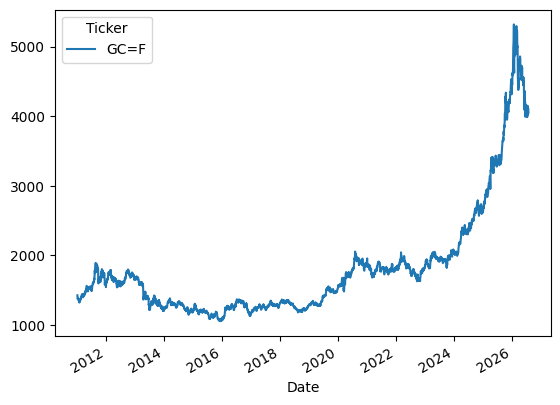

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2011-01-03,1422.599976,1423.900024,1413.699951,1415.599976,28
2011-01-04,1378.500000,1410.900024,1375.800049,1409.599976,122
2011-01-05,1373.400024,1384.000000,1364.199951,1383.400024,175
2011-01-06,1371.400024,1376.500000,1368.900024,1374.800049,158
2011-01-07,1368.500000,1377.199951,1355.500000,1372.699951,225


In [75]:
#黃金資料:gold_data  (此處為期貨價格 並取收盤價)資料區間為近15年(2011/1~2026/7)

gold_data = yf.download("GC=F", start_date , end_date)
gold_data["Close"].plot()
plt.show()
gold_data.head()

10年美債殖利率資料

判斷:10年期美債殖利率被視為全球金融資產的定價錨點與經濟晴雨表，其高檔震盪持續牽動股市評價、借貸成本與匯率走向

/tmp/ipykernel_5212/2493576454.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ten_year_US_Yield = yf.download("^TNX", start_date , end_date)
[*********************100%***********************]  1 of 1 completed


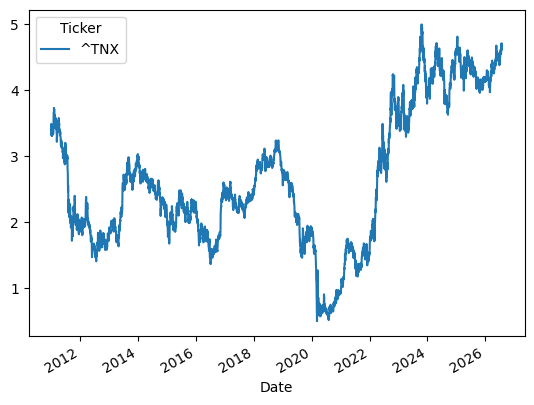

Price,Close,High,Low,Open,Volume
Ticker,^TNX,^TNX,^TNX,^TNX,^TNX
Date,,,,,
2011-01-03,3.342,3.420,3.313,3.377,0
2011-01-04,3.346,3.362,3.302,3.338,0
2011-01-05,3.483,3.497,3.379,3.381,0
2011-01-06,3.419,3.460,3.393,3.442,0
2011-01-07,3.328,3.464,3.297,3.435,0


In [76]:
#10年美債殖利率:ten_year_US_Yield

ten_year_US_Yield = yf.download("^TNX", start_date , end_date)
ten_year_US_Yield["Close"].plot()
plt.show()
ten_year_US_Yield.head()

布倫特原油資料

判斷:布倫特原油期貨合約是布倫特原油定價體系的一部分，包括現貨及遠期合約市場。該價格體系涵蓋了世界原油交易量的65%

/tmp/ipykernel_5212/2256896155.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  brent_oil = yf.download("CL=F", start_date , end_date)
[*********************100%***********************]  1 of 1 completed


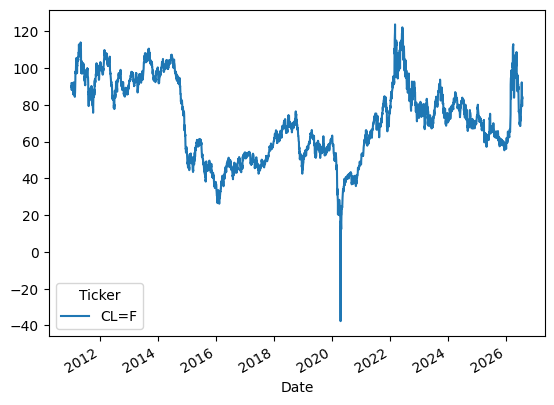

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,
2011-01-03,91.550003,92.580002,91.209999,91.309998,225189
2011-01-04,89.379997,92.070000,88.360001,91.500000,415521
2011-01-05,90.300003,90.839996,88.099998,89.290001,416908
2011-01-06,88.379997,90.709999,87.849998,90.470001,440456
2011-01-07,88.029999,89.480003,87.250000,88.180000,444813


In [77]:
brent_oil = yf.download("CL=F", start_date , end_date)
brent_oil["Close"].plot()
plt.show()
brent_oil.head()

道瓊工業指數dji

/tmp/ipykernel_5212/562961019.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dji = yf.download("^DJI", start_date , end_date)
[*********************100%***********************]  1 of 1 completed


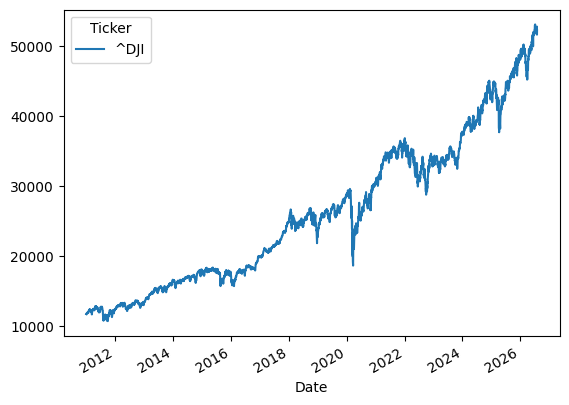

Price,Close,High,Low,Open,Volume
Ticker,^DJI,^DJI,^DJI,^DJI,^DJI
Date,,,,,
2011-01-03,11670.750000,11711.469727,11577.349609,11577.429688,203420000
2011-01-04,11691.179688,11698.219727,11635.740234,11670.900391,178630000
2011-01-05,11722.889648,11742.679688,11652.889648,11688.610352,169990000
2011-01-06,11697.309570,11736.740234,11667.459961,11716.929688,193080000
2011-01-07,11674.759766,11726.940430,11599.679688,11696.860352,188720000


In [78]:
dji = yf.download("^DJI", start_date , end_date)
dji ["Close"].plot()
plt.show()
dji.head()

德國的法蘭克福股價指數（DAX Index）

/tmp/ipykernel_5212/2245566228.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  de_stock = yf.download("^GDAXI", start_date , end_date)
[*********************100%***********************]  1 of 1 completed


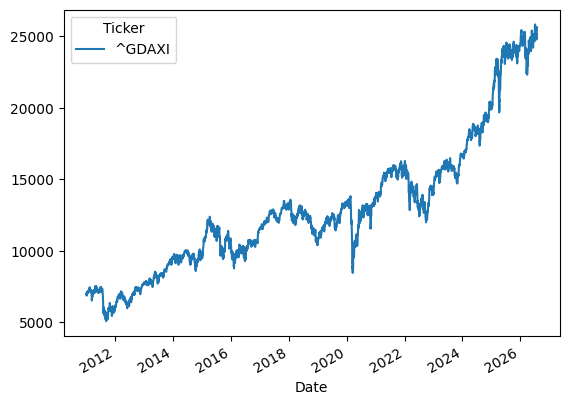

Price,Close,High,Low,Open,Volume
Ticker,^GDAXI,^GDAXI,^GDAXI,^GDAXI,^GDAXI
Date,,,,,
2011-01-03,6989.740234,7026.620117,6969.830078,6973.390137,61893200
2011-01-04,6975.350098,7025.859863,6952.020020,6979.680176,87665600
2011-01-05,6939.819824,6967.240234,6842.899902,6966.080078,117141900
2011-01-06,6981.390137,7047.589844,6949.069824,6949.479980,91236400
2011-01-07,6947.839844,7010.890137,6939.879883,6991.549805,92626900


In [79]:
de_stock = yf.download("^GDAXI", start_date , end_date)
de_stock ["Close"].plot()
plt.show()
de_stock.head()

日經指數（Nikkei）是日本東京證交所所編製的股價指數，是國際投資人在研究日本股市時一個重要的參考指數。日經指數亦有許多不同的系列指數，如最為人所熟知的日經225（Nikkei 225）即涵蓋了東京證交所裡最具代表性的225檔股票

/tmp/ipykernel_5212/930752109.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  jp_stock = yf.download("^N225", start_date , end_date)
[*********************100%***********************]  1 of 1 completed


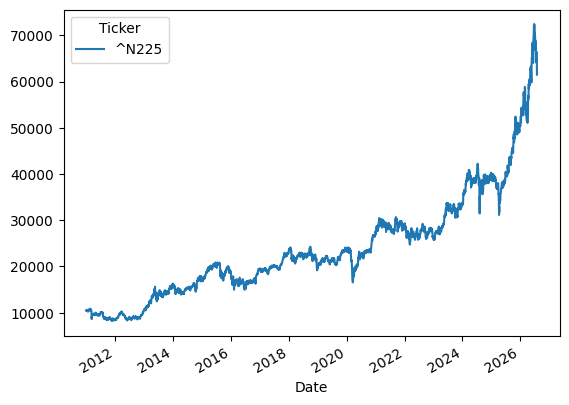

Price,Close,High,Low,Open,Volume
Ticker,^N225,^N225,^N225,^N225,^N225
Date,,,,,
2011-01-04,10398.099609,10409.169922,10321.280273,10352.190430,114100000
2011-01-05,10380.769531,10413.450195,10358.009766,10387.950195,114600000
2011-01-06,10529.759766,10530.110352,10477.519531,10477.519531,166000000
2011-01-07,10541.040039,10550.709961,10503.019531,10506.719727,161800000
2011-01-11,10510.679688,10538.389648,10476.290039,10484.620117,138500000


In [80]:
jp_stock = yf.download("^N225", start_date , end_date)
jp_stock ["Close"].plot()
plt.show()
jp_stock.head()

S & P 500指數

/tmp/ipykernel_5212/2346977932.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sap500 = yf.download("^GSPC", start_date , end_date)
[*********************100%***********************]  1 of 1 completed


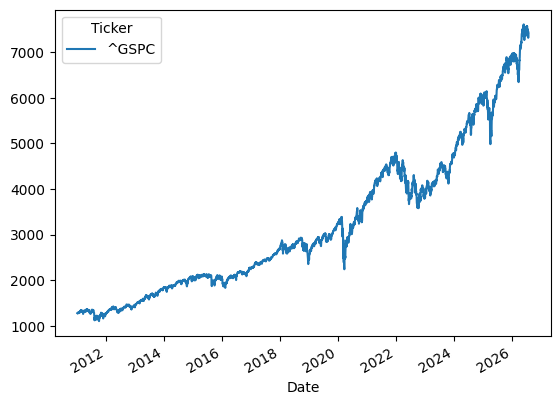

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2011-01-03,1271.869995,1276.170044,1257.619995,1257.619995,4286670000
2011-01-04,1270.199951,1274.119995,1262.660034,1272.949951,4796420000
2011-01-05,1276.560059,1277.630005,1265.359985,1268.780029,4764920000
2011-01-06,1273.849976,1278.170044,1270.430054,1276.290039,4844100000
2011-01-07,1271.500000,1276.829956,1261.699951,1274.410034,4963110000


In [81]:
sap500 = yf.download("^GSPC", start_date , end_date)
sap500 ["Close"].plot()
plt.show()
sap500.head()

VIX 指數（CBOE Volatility Index），俗稱「恐慌指數」，是芝加哥期權交易所用來衡量美國股市（S&P 500 指數）未來 30 天預期波動程度的指標。它反映了市場投資人對於未來股市風險與不確定性的心理預期。

/tmp/ipykernel_5212/1852966400.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix  = yf.download("^VIX", start_date , end_date)
[*********************100%***********************]  1 of 1 completed


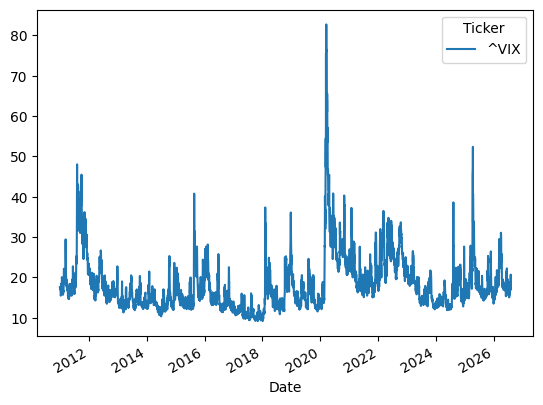

Price,Close,High,Low,Open,Volume
Ticker,^VIX,^VIX,^VIX,^VIX,^VIX
Date,,,,,
2011-01-03,17.610001,17.950001,16.910000,17.940001,0
2011-01-04,17.379999,18.240000,17.330000,17.340000,0
2011-01-05,17.020000,17.950001,16.860001,17.809999,0
2011-01-06,17.400000,17.559999,16.790001,16.799999,0
2011-01-07,17.139999,18.070000,16.570000,17.309999,0


In [82]:
vix  = yf.download("^VIX", start_date , end_date)
vix  ["Close"].plot()
plt.show()
vix.head()

NASDAQ Composite(^IXIC) 走勢圖


/tmp/ipykernel_5212/4276594119.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nasdaq  = yf.download("^IXIC", start_date , end_date)
[*********************100%***********************]  1 of 1 completed


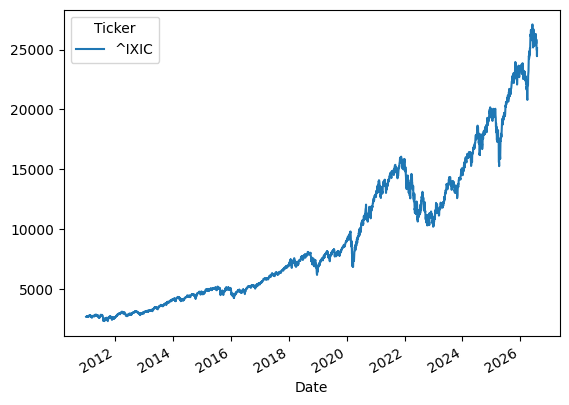

Price,Close,High,Low,Open,Volume
Ticker,^IXIC,^IXIC,^IXIC,^IXIC,^IXIC
Date,,,,,
2011-01-03,2691.520020,2704.860107,2676.340088,2676.649902,1919660000
2011-01-04,2681.250000,2700.879883,2663.639893,2699.860107,2015440000
2011-01-05,2702.199951,2702.199951,2671.889893,2673.909912,2060750000
2011-01-06,2709.889893,2712.350098,2697.729980,2704.379883,2095490000
2011-01-07,2703.169922,2715.959961,2676.360107,2712.750000,1976220000


In [83]:
nasdaq  = yf.download("^IXIC", start_date , end_date)
nasdaq  ["Close"].plot()
plt.show()
nasdaq.head()

台股加權指數

/tmp/ipykernel_5212/2941666604.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  twii  = yf.download("^TWII", start_date , end_date)
[*********************100%***********************]  1 of 1 completed


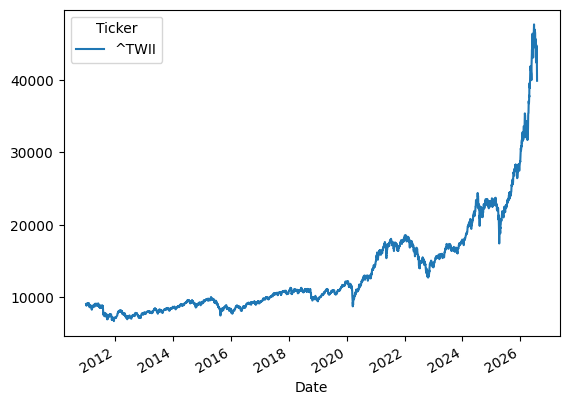

Price,Close,High,Low,Open,Volume
Ticker,^TWII,^TWII,^TWII,^TWII,^TWII
Date,,,,,
2011-01-03,9025.258789,9041.279224,8994.459124,9039.588802,5067400
2011-01-04,8997.149414,9046.138449,8988.539102,9045.069117,5270400
2011-01-05,8846.269531,9027.119299,8812.320466,9014.279513,5796600
2011-01-06,8883.168945,8883.168945,8813.589188,8866.189532,4362200
2011-01-07,8782.679688,8907.069745,8738.889848,8905.209402,4500800


In [84]:
twii  = yf.download("^TWII", start_date , end_date)
twii  ["Close"].plot()
plt.show()
twii.head()

/tmp/ipykernel_5212/3944052220.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tw_0051  = yf.download("0051.TW", start_date , end_date)
[*********************100%***********************]  1 of 1 completed


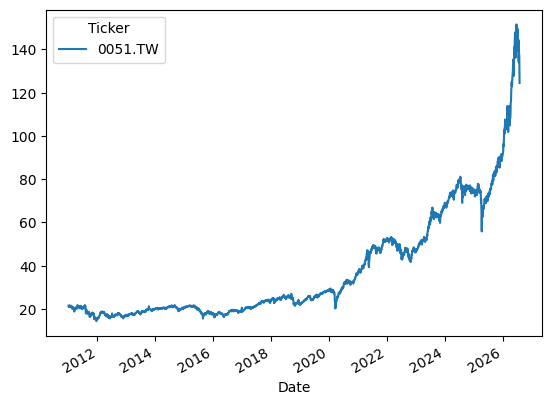

Price,Close,High,Low,Open,Volume
Ticker,^TWII,^TWII,^TWII,^TWII,^TWII
Date,,,,,
2011-01-03,9025.258789,9041.279224,8994.459124,9039.588802,5067400
2011-01-04,8997.149414,9046.138449,8988.539102,9045.069117,5270400
2011-01-05,8846.269531,9027.119299,8812.320466,9014.279513,5796600
2011-01-06,8883.168945,8883.168945,8813.589188,8866.189532,4362200
2011-01-07,8782.679688,8907.069745,8738.889848,8905.209402,4500800


In [85]:
tw_0051  = yf.download("0051.TW", start_date , end_date)
tw_0051  ["Close"].plot()
plt.show()
twii.head()

美國CPI(美國消費者物價指數)年增率(YoY)

原始 CPI 指數去計算 YoY（公式：$\frac{\text{CPI}_t}{\text{CPI}_{t-12}} - 1$）：

=== 最終檢查 ===
資料總筆數: 4065
是否存在任何 NaN: False

首 5 筆資料:
             CPI_YoY
Date                
2011-01-03  1.700783
2011-01-04  1.700783
2011-01-05  1.700783
2011-01-06  1.700783
2011-01-07  1.700783

末 5 筆資料:
             CPI_YoY
Date                
2026-07-27  3.463531
2026-07-28  3.463531
2026-07-29  3.463531
2026-07-30  3.463531
2026-07-31  3.463531


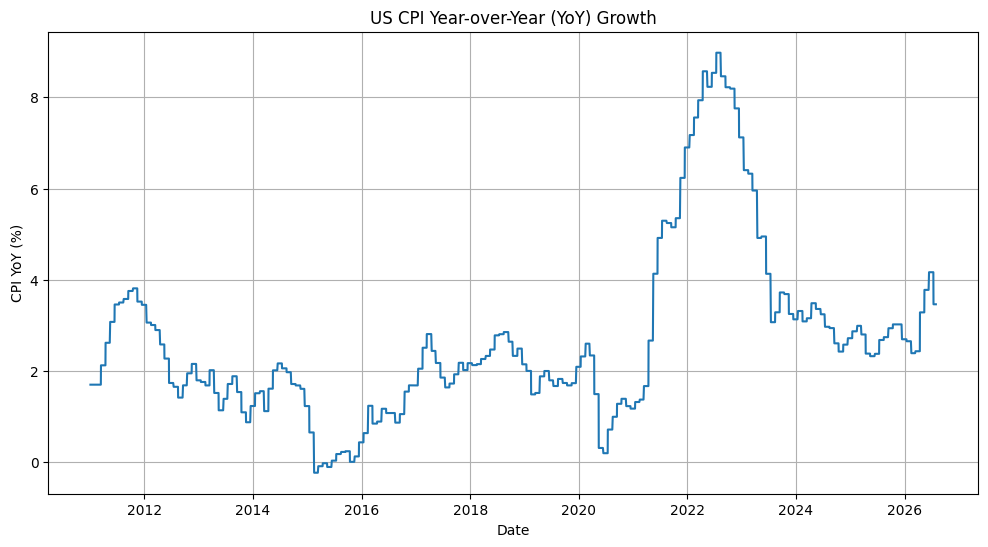

,CPI_YoY
Date,
2011-01-03,1.700783
2011-01-04,1.700783
2011-01-05,1.700783
2011-01-06,1.700783
2011-01-07,1.700783


In [86]:
#總經數據無法從yfinance上下載 從美國FRED抓取
import pandas_datareader.data as web
import datetime
from dateutil.relativedelta import relativedelta

# 設定時間範圍
# 將 start_date 從字串轉換為 datetime 物件，才能與 relativedelta 進行運算
start_date_obj = datetime.datetime.strptime(start_date, '%Y-%m-%d')
date_reduce_1y = start_date_obj - relativedelta(years=1)

# 將 end_date 從字串轉換為 datetime 物件，用於 FRED 資料讀取
end_date_obj = datetime.datetime.strptime(end_date, '%Y-%m-%d')
# 1. 抓取資料
cpi_raw = web.DataReader("CPIAUCSL", "fred", date_reduce_1y, end_date_obj)
cpi_raw.index.name = "Date"

# 計算 YoY 並切除前 12 個月（切除後資料剛好從 2011-01-01 開始）
cpi_raw["CPI_YoY"] = cpi_raw["CPIAUCSL"].pct_change(12, fill_method=None) * 100
cpi_df = cpi_raw.iloc[12:].copy()

# 2. 模擬實際發布日（推遲 1 個月又 14 天，即次月 15 號發布）
# 如果你的 Date 欄位本身已經是發布日，可直接將此行註解掉
cpi_df['Release_Date'] = cpi_df.index + pd.DateOffset(months=1, days=14)
cpi_df = cpi_df.reset_index().set_index('Release_Date')[['CPI_YoY']]

# 3. 建立目標日線框架（對應 yfinance 的台美股營業日，頻率設為 'B'）
daily_idx = pd.date_range(start=start_date, end=end_date, freq="B")
daily_df = pd.DataFrame(index=daily_idx)
daily_df.index.name = "Date"

# 4. 轉換格式以進行 merge_asof 安全對齊
daily_df = daily_df.reset_index()
cpi_df = cpi_df.reset_index()

# 嚴格向後對齊（direction='backward'），確保絕不洩漏未來資料
final_cpi_daily = pd.merge_asof(
    daily_df,
    cpi_df,
    left_on="Date",
    right_on="Release_Date",
    direction="backward"
)

# 5. 清理欄位並確保零 NaN
final_cpi_daily = final_cpi_daily.set_index("Date")[['CPI_YoY']]

# 執行雙向填補：ffill 確保日常發布空白處被填滿，bfill 確保 2011 年初極少數可能因假日產生的空缺被補齊
final_cpi_daily = final_cpi_daily.ffill().bfill()

# --- 驗證結果 ---
print("=== 最終檢查 ===")
print(f"資料總筆數: {len(final_cpi_daily)}")
print(f"是否存在任何 NaN: {final_cpi_daily.isna().any().values[0]}")
print("\n首 5 筆資料:")
print(final_cpi_daily.head())
print("\n末 5 筆資料:")
print(final_cpi_daily.tail())


plt.figure(figsize=(12, 6))
plt.plot(final_cpi_daily.index, final_cpi_daily['CPI_YoY'])
plt.title('US CPI Year-over-Year (YoY) Growth')
plt.xlabel('Date')
plt.ylabel('CPI YoY (%)')
plt.grid(True)
plt.show()

final_cpi_daily.head()

氣對抗與經濟擴張脈搏（決定大盤多空基調）
FRED 代號：T10Y2Y（美國 10 年期公債減 2 年期公債殖利率利差，即 殖利率曲線倒掛指標）或台灣自身的領先指標。若純看全球宏觀與台股連動，美債利差最具代表性；若要專注台灣，可看台灣出口年增率。

經濟學家視角：這是全球公認最強的經濟衰退預警器。

股票分析師視角：台股高度依賴全球景氣與外資動向，當利差倒掛解除、經濟從谷底回升時，往往是電子權值股（如台積電、鴻海）展開大波段多頭的起手式。

=== 最終檢查 (T10Y2Y Spread) ===
資料總筆數: 4065
是否存在任何 NaN: False

首 5 筆資料:
            T10Y2Y
Date              
2011-01-03    2.75
2011-01-04    2.73
2011-01-05    2.79
2011-01-06    2.76
2011-01-07    2.74

末 5 筆資料:
            T10Y2Y
Date              
2026-07-27    0.34
2026-07-28    0.35
2026-07-29    0.45
2026-07-30    0.45
2026-07-31    0.47


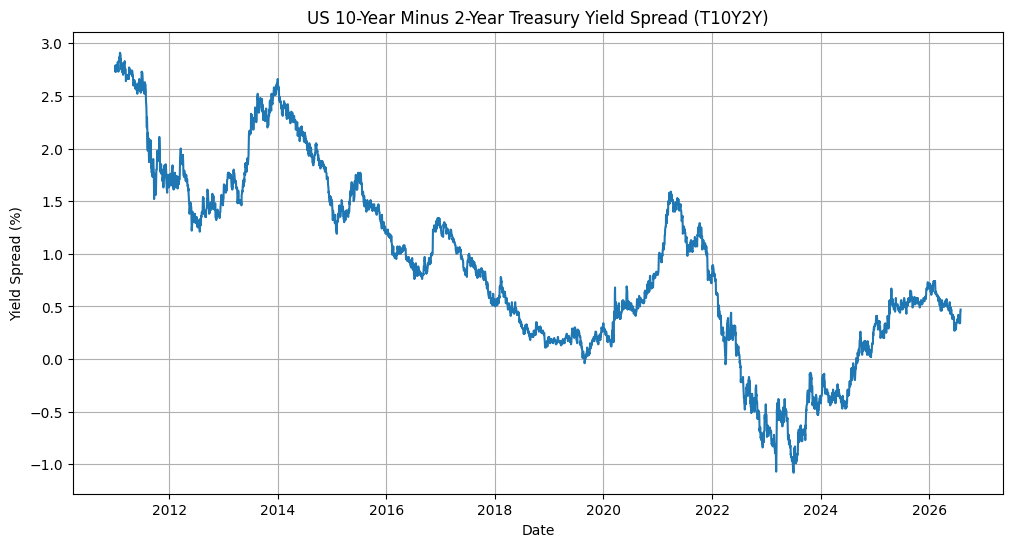


T10Y2Y_Spread series head:


,T10Y2Y_Spread
Date,
2011-01-03,2.75
2011-01-04,2.73
2011-01-05,2.79
2011-01-06,2.76
2011-01-07,2.74


In [103]:

# 設定時間範圍
# 為了避免重複執行導致的 TypeError，確保 start_date 和 end_date 變數始終為字串。
# 如果它們在 kernel 中被錯誤地變成了 datetime 物件，則將其轉換回字串。
if isinstance(start_date, datetime.datetime):
    start_date = start_date.strftime('%Y-%m-%d')
if isinstance(end_date, datetime.datetime):
    end_date = end_date.strftime('%Y-%m-%d')

start_date_fred = datetime.datetime.strptime(start_date, '%Y-%m-%d')
end_date_fred = datetime.datetime.strptime(end_date, '%Y-%m-%d')

# 1. 抓取 T10Y2Y 資料
# T10Y2Y: 10-Year Treasury Constant Maturity Minus 2-Year Treasury Constant Maturity
t10y2y_raw = web.DataReader("T10Y2Y", "fred", start_date_fred, end_date_fred)
t10y2y_raw.index.name = "Date"

# 2. 建立目標日線框架（對應 yfinance 的台美股營業日，頻率設為 'B'）
daily_idx = pd.date_range(start=start_date_fred, end=end_date_fred, freq="B")
daily_df_t10y2y = pd.DataFrame(index=daily_idx)
daily_df_t10y2y.index.name = "Date"

# 3. 轉換格式以進行 merge_asof 安全對齊
daily_df_t10y2y = daily_df_t10y2y.reset_index()
t10y2y_df_aligned = t10y2y_raw.reset_index()

# 嚴格向後對齊（direction='backward'），確保絕不洩漏未來資料
# T10Y2Y 是每日資料，其發布日即為資料日期本身，故無需像 CPI 那樣進行 release_date 偏移
final_t10y2y_daily = pd.merge_asof(
    daily_df_t10y2y,
    t10y2y_df_aligned,
    left_on="Date",
    right_on="Date",
    direction="backward"
)

# 4. 清理欄位並確保零 NaN
final_t10y2y_daily = final_t10y2y_daily.set_index("Date")[['T10Y2Y']]

# 執行雙向填補：ffill 確保日常發布空白處被填滿，bfill 確保 2011 年初可能因假日產生的空缺被補齊
final_t10y2y_daily = final_t10y2y_daily.ffill().bfill()

# 將結果儲存為 t10y2y_series，以便後續合併使用
t10y2y_series = final_t10y2y_daily['T10Y2Y']
t10y2y_series.name = 'T10Y2Y_Spread' # Renaming for clarity in case of conflict

# --- 驗證結果 ---
print("=== 最終檢查 (T10Y2Y Spread) ===")
print(f"資料總筆數: {len(final_t10y2y_daily)}")
print(f"是否存在任何 NaN: {final_t10y2y_daily.isna().any().values[0]}")
print("\n首 5 筆資料:")
print(final_t10y2y_daily.head())
print("\n末 5 筆資料:")
print(final_t10y2y_daily.tail())

plt.figure(figsize=(12, 6))
plt.plot(final_t10y2y_daily.index, final_t10y2y_daily['T10Y2Y'])
plt.title('US 10-Year Minus 2-Year Treasury Yield Spread (T10Y2Y)')
plt.xlabel('Date')
plt.ylabel('Yield Spread (%)')
plt.grid(True)
plt.show()

# Display head of the final series
print("\nT10Y2Y_Spread series head:")
display(t10y2y_series.head())

=== 最終檢查 (台灣出口年增率) ===
資料總筆數: 4065
是否存在任何 NaN: False

首 5 筆資料:
            Taiwan_Export_YoY
Date                         
2011-01-03         -16.690042
2011-01-04         -16.690042
2011-01-05         -16.690042
2011-01-06         -16.690042
2011-01-07         -16.690042

末 5 筆資料:
            Taiwan_Export_YoY
Date                         
2026-07-27          38.675893
2026-07-28          38.675893
2026-07-29          38.675893
2026-07-30          38.675893
2026-07-31          38.675893


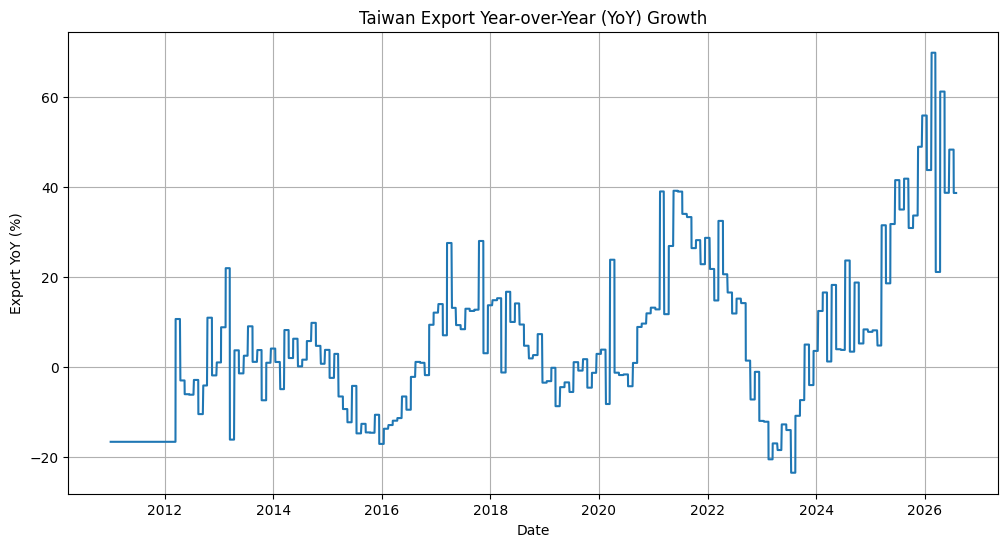


Taiwan_Export_YoY series head:


,Taiwan_Export_YoY
Date,
2011-01-03,-16.690042
2011-01-04,-16.690042
2011-01-05,-16.690042
2011-01-06,-16.690042
2011-01-07,-16.690042


In [104]:
import pandas_datareader.data as web
import datetime
import pandas as pd
import matplotlib.pyplot as plt


# 設定時間範圍 (與其他 FRED 數據保持一致)
# 為了避免重複執行導致的 TypeError，確保 start_date 和 end_date 變數始終為字串。
# 如果它們在 kernel 中被錯誤地變成了 datetime 物件，則將其轉換回字串。
if isinstance(start_date, datetime.datetime):
    start_date = start_date.strftime('%Y-%m-%d')
if isinstance(end_date, datetime.datetime):
    end_date = end_date.strftime('%Y-%m-%d')

start_date_fred = datetime.datetime.strptime(start_date, '%Y-%m-%d')
end_date_fred = datetime.datetime.strptime(end_date, '%Y-%m-%d')

# 1. 從 FRED 抓取台灣出口總值原始數據
taiwan_export_raw = web.DataReader("VALEXPTWM052N", "fred", start_date_fred, end_date_fred)
taiwan_export_raw.index.name = "Date"

# 2. 計算台灣出口年增率 (Export YoY)
# pct_change(12) 會產生前 12 個月的 NaN
taiwan_export_raw["Taiwan_Export_YoY"] = taiwan_export_raw["VALEXPTWM052N"].pct_change(12) * 100

# 移除因計算 YoY 產生的前 12 個月 NaN，並確保資料從指定開始日期之後
taiwan_export_df = taiwan_export_raw.loc[taiwan_export_raw.index >= start_date_fred].iloc[12:].copy()

# 3. 模擬實際發布日（推遲 1 個月又 14 天，即次月 15 號發布，與 CPI 處理邏輯一致）
# 將原始月度日期向前推移一個月，然後加上 14 天，作為「發布日」
taiwan_export_df['Release_Date'] = taiwan_export_df.index + pd.DateOffset(months=1, days=14)
# 將索引設置為 Release_Date，並只保留 'Taiwan_Export_YoY' 欄位
taiwan_export_df = taiwan_export_df.reset_index().set_index('Release_Date')[['Taiwan_Export_YoY']]

# 4. 建立目標日線框架（對應 yfinance 的台美股營業日，頻率設為 'B'）
daily_idx = pd.date_range(start=start_date_fred, end=end_date_fred, freq="B")
daily_df_export = pd.DataFrame(index=daily_idx)
daily_df_export.index.name = "Date"

# 5. 轉換格式以進行 merge_asof 安全對齊
daily_df_export = daily_df_export.reset_index()
export_df_aligned = taiwan_export_df.reset_index()

# 嚴格向後對齊（direction='backward'），確保絕不洩漏未來資料
final_taiwan_export_daily = pd.merge_asof(
    daily_df_export,
    export_df_aligned,
    left_on="Date",
    right_on="Release_Date",
    direction="backward"
)

# 6. 清理欄位並確保零 NaN
final_taiwan_export_daily = final_taiwan_export_daily.set_index("Date")[['Taiwan_Export_YoY']]

# 執行雙向填補：ffill 確保日常發布空白處被填滿，bfill 確保開頭可能因假日產生的空缺被補齊
final_taiwan_export_daily = final_taiwan_export_daily.ffill().bfill()

# 將結果儲存為 taiwan_export_series，以便後續合併使用
taiwan_export_series = final_taiwan_export_daily['Taiwan_Export_YoY']
taiwan_export_series.name = 'Taiwan_Export_YoY' # 確保名稱清晰

# --- 驗證結果 ---
print("=== 最終檢查 (台灣出口年增率) ===")
print(f"資料總筆數: {len(final_taiwan_export_daily)}")
print(f"是否存在任何 NaN: {final_taiwan_export_daily.isna().any().values[0]}")
print("\n首 5 筆資料:")
print(final_taiwan_export_daily.head())
print("\n末 5 筆資料:")
print(final_taiwan_export_daily.tail())

plt.figure(figsize=(12, 6))
plt.plot(final_taiwan_export_daily.index, final_taiwan_export_daily['Taiwan_Export_YoY'])
plt.title('Taiwan Export Year-over-Year (YoY) Growth')
plt.xlabel('Date')
plt.ylabel('Export YoY (%)')
plt.grid(True)
plt.show()

# Display head of the final series
print("\nTaiwan_Export_YoY series head:")
display(taiwan_export_series.head())

In [89]:
# 合併所有數據到一個 DataFrame，使用原始的 'Close' 價格（不平滑），以及 CPI_YoY

# 初始化合併的 DataFrame，以一個數據集的索引為基礎
yf_macroeconomics = pd.DataFrame(index=gold_data.index)

# 合併黃金數據的 'Close' 價格
gold_close = gold_data['Close']
gold_close.name = 'Gold_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, gold_close], axis=1)

# 合併10年美債殖利率數據的 'Close' 價格
us10y_yield_close = ten_year_US_Yield['Close']
us10y_yield_close.name = 'US10Y_Yield_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, us10y_yield_close], axis=1)

# 合併布倫特原油數據的 'Close' 價格
brent_oil_close = brent_oil['Close']
brent_oil_close.name = 'Brent_Oil_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, brent_oil_close], axis=1)

# 合併道瓊工業指數數據的 'Close' 價格
dji_close = dji['Close']
dji_close.name = 'DJI_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, dji_close], axis=1)

# 合併德國法蘭克福股價指數數據的 'Close' 價格
de_stock_close = de_stock['Close']
de_stock_close.name = 'DAX_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, de_stock_close], axis=1)

# 合併日經指數數據的 'Close' 價格
jp_stock_close = jp_stock['Close']
jp_stock_close.name = 'Nikkei_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, jp_stock_close], axis=1)

# 合併S&P 500指數數據的 'Close' 價格
sap500_close = sap500['Close']
sap500_close.name = 'SP500_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, sap500_close], axis=1)

# 合併VIX指數數據的 'Close' 價格
vix_close = vix['Close']
vix_close.name = 'VIX_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, vix_close], axis=1)

# 合併NASDAQ綜合指數數據的 'Close' 價格
nasdaq_close = nasdaq['Close']
nasdaq_close.name = 'NASDAQ_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, nasdaq_close], axis=1)

# 合併台灣加權指數數據的 'Close' 價格
twii_close = twii['Close']
twii_close.name = 'TWII_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, twii_close], axis=1)

# 合併tw_0051數據的 'Close' 價格
tw_0051_close = tw_0051['Close']
tw_0051_close.name = '0051TW_Close'
yf_macroeconomics = pd.concat([yf_macroeconomics, tw_0051_close], axis=1)

# 合併 CPI YoY 數據 (該數據已經過預處理並按日對齊)
cpi_yoy_series = final_cpi_daily['CPI_YoY']
cpi_yoy_series.name = 'CPI_YoY'
yf_macroeconomics = pd.concat([yf_macroeconomics, cpi_yoy_series], axis=1)

# 合併 T10Y2Y 數據 (該數據已經過預處理並按日對齊)
t10y2y_series.name = 'T10Y2Y_Spread'
yf_macroeconomics = pd.concat([yf_macroeconomics, t10y2y_series], axis=1)

# 合併 台灣出口年增率數據 (該數據已經過預處理並按日對齊)
taiwan_export_series.name = 'Taiwan_Export_YoY'
yf_macroeconomics = pd.concat([yf_macroeconomics, taiwan_export_series], axis=1)


# 顯示合併後的數據的前幾行和數據類型資訊
print("合併後的數據 (yf_macroeconomics) 的前5行：")
display(yf_macroeconomics.head())
print("合併後的數據 (yf_macroeconomics) 的基本資訊：")
yf_macroeconomics.info()

合併後的數據 (yf_macroeconomics) 的前5行：


,GC=F,^TNX,CL=F,^DJI,^GDAXI,^N225,^GSPC,^VIX,^IXIC,^TWII,0051.TW,CPI_YoY,T10Y2Y_Spread,Taiwan_Export_YoY
Date,,,,,,,,,,,,,,
2011-01-03,1422.599976,3.342,91.550003,11670.750000,6989.740234,NaN,1271.869995,17.610001,2691.520020,9025.258789,21.589506,1.700783,2.75,-16.690042
2011-01-04,1378.500000,3.346,89.379997,11691.179688,6975.350098,10398.099609,1270.199951,17.379999,2681.250000,8997.149414,21.377323,1.700783,2.73,-16.690042
2011-01-05,1373.400024,3.483,90.300003,11722.889648,6939.819824,10380.769531,1276.560059,17.020000,2702.199951,8846.269531,21.072309,1.700783,2.79,-16.690042
2011-01-06,1371.400024,3.419,88.379997,11697.309570,6981.390137,10529.759766,1273.849976,17.400000,2709.889893,8883.168945,21.330908,1.700783,2.76,-16.690042
2011-01-07,1368.500000,3.328,88.029999,11674.759766,6947.839844,10541.040039,1271.500000,17.139999,2703.169922,8782.679688,20.946329,1.700783,2.74,-16.690042


合併後的數據 (yf_macroeconomics) 的基本資訊：
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4070 entries, 2011-01-03 to 2026-07-31
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GC=F               3915 non-null   float64
 1   ^TNX               3915 non-null   float64
 2   CL=F               3916 non-null   float64
 3   ^DJI               3916 non-null   float64
 4   ^GDAXI             3950 non-null   float64
 5   ^N225              3810 non-null   float64
 6   ^GSPC              3916 non-null   float64
 7   ^VIX               3917 non-null   float64
 8   ^IXIC              3916 non-null   float64
 9   ^TWII              3795 non-null   float64
 10  0051.TW            3807 non-null   float64
 11  CPI_YoY            4065 non-null   float64
 12  T10Y2Y_Spread      4065 non-null   float64
 13  Taiwan_Export_YoY  4065 non-null   float64
dtypes: float64(14)
memory usage: 477.0 KB


In [90]:
# 對 yf_macroeconomics 中的數據進行平滑化處理
yf_macroeconomics_smoothed = pd.DataFrame(index=yf_macroeconomics.index)

# 遍歷 yf_macroeconomics 的每一列
for column in yf_macroeconomics.columns:
    if column == 'CPI_YoY':
        # CPI_YoY 已經是處理過的總經數據，不進行額外平滑
        yf_macroeconomics_smoothed[column] = yf_macroeconomics[column]
    else:
        # 對其他金融數據進行30天滾動平均平滑
        yf_macroeconomics_smoothed[column] = yf_macroeconomics[column].rolling(window=30, min_periods=1).mean()


print("平滑化處理後的數據 (yf_macroeconomics_smoothed) 的前5行：")
display(yf_macroeconomics_smoothed.head())
print("平滑化處理後的數據 (yf_macroeconomics_smoothed) 的基本資訊：")
yf_macroeconomics_smoothed.info()

平滑化處理後的數據 (yf_macroeconomics_smoothed) 的前5行：


,GC=F,^TNX,CL=F,^DJI,^GDAXI,^N225,^GSPC,^VIX,^IXIC,^TWII,0051.TW,CPI_YoY,T10Y2Y_Spread,Taiwan_Export_YoY
Date,,,,,,,,,,,,,,
2011-01-03,1422.599976,3.342000,91.550003,11670.750000,6989.740234,NaN,1271.869995,17.610001,2691.520020,9025.258789,21.589506,1.700783,2.750000,-16.690042
2011-01-04,1400.549988,3.344000,90.465000,11680.964844,6982.545166,10398.099609,1271.034973,17.495000,2686.385010,9011.204102,21.483415,1.700783,2.740000,-16.690042
2011-01-05,1391.500000,3.390333,90.410001,11694.939779,6968.303385,10389.434570,1272.876668,17.336667,2691.656657,8956.225911,21.346380,1.700783,2.756667,-16.690042
2011-01-06,1386.475006,3.397500,89.902500,11695.532227,6971.575073,10436.209635,1273.119995,17.352500,2696.214966,8937.961670,21.342512,1.700783,2.757500,-16.690042
2011-01-07,1382.880005,3.383600,89.528000,11691.377734,6966.828027,10462.417236,1272.795996,17.310000,2697.605957,8906.905273,21.263275,1.700783,2.754000,-16.690042


平滑化處理後的數據 (yf_macroeconomics_smoothed) 的基本資訊：
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4070 entries, 2011-01-03 to 2026-07-31
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GC=F               4070 non-null   float64
 1   ^TNX               4070 non-null   float64
 2   CL=F               4070 non-null   float64
 3   ^DJI               4070 non-null   float64
 4   ^GDAXI             4070 non-null   float64
 5   ^N225              4069 non-null   float64
 6   ^GSPC              4070 non-null   float64
 7   ^VIX               4070 non-null   float64
 8   ^IXIC              4070 non-null   float64
 9   ^TWII              4070 non-null   float64
 10  0051.TW            4070 non-null   float64
 11  CPI_YoY            4065 non-null   float64
 12  T10Y2Y_Spread      4070 non-null   float64
 13  Taiwan_Export_YoY  4070 non-null   float64
dtypes: float64(14)
memory usage: 477.0 KB


#### 台灣個股群

/tmp/ipykernel_5212/3668339227.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tsmc  = yf.download("2330.TW", start_date , end_date)
[*********************100%***********************]  1 of 1 completed


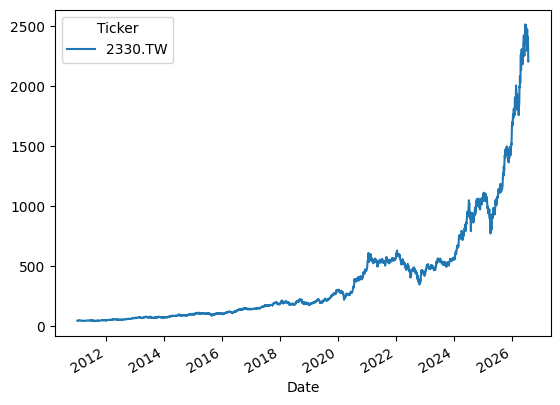

Price,Close,High,Low,Open,Volume
Ticker,^TWII,^TWII,^TWII,^TWII,^TWII
Date,,,,,
2011-01-03,9025.258789,9041.279224,8994.459124,9039.588802,5067400
2011-01-04,8997.149414,9046.138449,8988.539102,9045.069117,5270400
2011-01-05,8846.269531,9027.119299,8812.320466,9014.279513,5796600
2011-01-06,8883.168945,8883.168945,8813.589188,8866.189532,4362200
2011-01-07,8782.679688,8907.069745,8738.889848,8905.209402,4500800


In [91]:
tsmc  = yf.download("2330.TW", start_date , end_date)
tsmc  ["Close"].plot()
plt.show()
twii.head()

In [92]:
# 定義你的各產業龍頭清單 (Yahoo Finance 代號格式)
sector_leaders = {
    "TSMC": "2330.TW",   # 半導體
    "MediaTek": "2454.TW", # IC設計
    "Delta": "2308.TW",    # 電源/散熱
    "HonHai": "2317.TW",   # 電子代工
    "Quanta": "2382.TW",   # 伺服器/廣達
    "FubonFin": "2881.TW", # 金融
    "Chunghwa": "2412.TW", # 電信
    "Evergreen": "2603.TW" # 航運
}

# Use the defined start_date and end_date variables


# 1. 批次抓取收盤價 (Adj.Close)
symbols_tw_stock = list(sector_leaders.values())
prices_tw_stock = yf.download(symbols_tw_stock, start=start_date, end=end_date)["Close"]


# 2. 【核心套用】：30天區間平滑 (Rolling Mean) 濾除短線雜訊
smoothed_tw_price = prices_tw_stock.rolling(window=30, min_periods=30).mean()

# 3. 【核心套用】：Z-Score 標準化 (讓不同股價級距的個股拉到同一刻度)
# 公式: (x - mean) / std
z_scored_df = (smoothed_tw_price - smoothed_tw_price.mean()) / smoothed_tw_price.std()

# 4. 刪除因為 30 天滾動產生的前端 NaN
features_df = z_scored_df.dropna()

print("=== 個股多維特徵處理完成 ===")
print(f"資料形狀 (Rows, Columns): {features_df.shape}")
print(features_df.tail())

/tmp/ipykernel_5212/2729276505.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices_tw_stock = yf.download(symbols_tw_stock, start=start_date, end=end_date)["Close"]
[*********************100%***********************]  8 of 8 completed

=== 個股多維特徵處理完成 ===
資料形狀 (Rows, Columns): (3772, 8)
Ticker       2308.TW   2317.TW   2330.TW   2382.TW   2412.TW   2454.TW  \
Date                                                                     
2026-07-24  5.444429  3.351894  4.585262  3.154685  2.330541  6.263061   
2026-07-27  5.397089  3.351917  4.588283  3.141076  2.331805  6.234960   
2026-07-28  5.331801  3.336813  4.581108  3.124890  2.333095  6.168226   
2026-07-29  5.255441  3.320005  4.566003  3.109955  2.332342  6.086443   
2026-07-30  5.189467  3.295971  4.552408  3.078764  2.332934  6.015566   

Ticker       2603.TW   2881.TW  
Date                            
2026-07-24  2.363701  3.986961  
2026-07-27  2.359315  4.004603  
2026-07-28  2.354789  4.007814  
2026-07-29  2.353135  4.000953  
2026-07-30  2.356994  3.990587  


### 第一段線上資料自動化驗證

先合併平滑後函數為測試資料集

In [93]:
tick001_testdf = pd.merge(
    features_df,
    yf_macroeconomics_smoothed,
    left_index=True,
    right_index=True,
    how='outer'
)

# 處理可能由於合併導致的 NaN 值，先向前填充再向後填充
tick001_testdf = tick001_testdf.ffill().bfill()

print("合併後的數據 (tick001_testdf) 的前5行：")
display(tick001_testdf.head())
print("合併後的數據 (tick001_testdf) 的基本資訊：")
tick001_testdf.info()
print("合併後的數據 (tick001_testdf) 的後5行：")
display(tick001_testdf.tail())

合併後的數據 (tick001_testdf) 的前5行：


,2308.TW,2317.TW,2330.TW,2382.TW,2412.TW,2454.TW,2603.TW,2881.TW,GC=F,^TNX,...,^GDAXI,^N225,^GSPC,^VIX,^IXIC,^TWII,0051.TW,CPI_YoY,T10Y2Y_Spread,Taiwan_Export_YoY
Date,,,,,,,,,,,,,,,,,,,,,
2011-01-03,-0.494366,-0.734598,-0.770198,-0.678546,-1.613393,-0.558566,-0.538835,-0.926478,1422.599976,3.342000,...,6989.740234,10398.099609,1271.869995,17.610001,2691.520020,9025.258789,21.589506,1.700783,2.750000,-16.690042
2011-01-04,-0.494366,-0.734598,-0.770198,-0.678546,-1.613393,-0.558566,-0.538835,-0.926478,1400.549988,3.344000,...,6982.545166,10398.099609,1271.034973,17.495000,2686.385010,9011.204102,21.483415,1.700783,2.740000,-16.690042
2011-01-05,-0.494366,-0.734598,-0.770198,-0.678546,-1.613393,-0.558566,-0.538835,-0.926478,1391.500000,3.390333,...,6968.303385,10389.434570,1272.876668,17.336667,2691.656657,8956.225911,21.346380,1.700783,2.756667,-16.690042
2011-01-06,-0.494366,-0.734598,-0.770198,-0.678546,-1.613393,-0.558566,-0.538835,-0.926478,1386.475006,3.397500,...,6971.575073,10436.209635,1273.119995,17.352500,2696.214966,8937.961670,21.342512,1.700783,2.757500,-16.690042
2011-01-07,-0.494366,-0.734598,-0.770198,-0.678546,-1.613393,-0.558566,-0.538835,-0.926478,1382.880005,3.383600,...,6966.828027,10462.417236,1272.795996,17.310000,2697.605957,8906.905273,21.263275,1.700783,2.754000,-16.690042


合併後的數據 (tick001_testdf) 的基本資訊：
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4070 entries, 2011-01-03 to 2026-07-31
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   2308.TW            4070 non-null   float64
 1   2317.TW            4070 non-null   float64
 2   2330.TW            4070 non-null   float64
 3   2382.TW            4070 non-null   float64
 4   2412.TW            4070 non-null   float64
 5   2454.TW            4070 non-null   float64
 6   2603.TW            4070 non-null   float64
 7   2881.TW            4070 non-null   float64
 8   GC=F               4070 non-null   float64
 9   ^TNX               4070 non-null   float64
 10  CL=F               4070 non-null   float64
 11  ^DJI               4070 non-null   float64
 12  ^GDAXI             4070 non-null   float64
 13  ^N225              4070 non-null   float64
 14  ^GSPC              4070 non-null   float64
 15  ^VIX               4070

,2308.TW,2317.TW,2330.TW,2382.TW,2412.TW,2454.TW,2603.TW,2881.TW,GC=F,^TNX,...,^GDAXI,^N225,^GSPC,^VIX,^IXIC,^TWII,0051.TW,CPI_YoY,T10Y2Y_Spread,Taiwan_Export_YoY
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-27,5.397089,3.351917,4.588283,3.141076,2.331805,6.234960,2.359315,4.004603,4095.528582,4.525071,...,25064.345964,68526.891433,7471.320748,17.263571,25812.191755,45441.184431,143.870691,3.463531,0.341333,45.431632
2026-07-28,5.331801,3.336813,4.581108,3.124890,2.333095,6.168226,2.354789,4.007814,4085.007159,4.531357,...,25082.799284,68284.147360,7468.371809,17.327857,25758.640695,45290.976144,143.410346,3.463531,0.340333,45.109930
2026-07-29,5.255441,3.320005,4.566003,3.109955,2.332342,6.086443,2.353135,4.000953,4073.428589,4.537036,...,25100.326302,67992.145339,7464.659302,17.407143,25702.257812,45082.468610,142.770691,3.463531,0.345667,44.788228
2026-07-30,5.189467,3.295971,4.552408,3.078764,2.332934,6.015566,2.356994,3.990587,4069.000017,4.544607,...,25119.833919,67675.384564,7462.411080,17.431786,25652.409598,44849.186523,141.968967,3.463531,0.351667,44.466526
2026-07-31,5.189467,3.295971,4.552408,3.078764,2.332934,6.015566,2.356994,3.990587,4069.000017,4.544607,...,25124.455078,67547.717494,7462.411080,17.431786,25652.409598,44849.186523,141.968967,3.463531,0.358333,44.144824


自動化測試

In [94]:
import pytest

def test_consolidated_feature_matrix(target_feature_df: pd.DataFrame):
    """
    驗證整合後的總體與市場特徵矩陣 (tick001_testdf) 是否符合訓練標準
    """
    # 1. 基礎防禦：確認 DataFrame 不為空
    assert not target_feature_df.empty, "測試失敗：特徵矩陣為空，無任何數據"

    # 2. 關鍵欄位存在性檢查（確保個股與宏觀核心指標都有進來）
    critical_columns = ['2330.TW', '^VIX', 'CPI_YoY']
    for col in critical_columns:
        assert col in target_feature_df.columns, f"測試失敗：特徵矩陣中缺少關鍵欄位 [{col}]"

    # 3. 零 NaN 鐵律檢查（驗證前期的 ffill/bfill 與 rolling 刪除是否有確實執行）
    total_nan_count = target_feature_df.isna().sum().sum()
    assert total_nan_count == 0, f"測試失敗：特徵矩陣中仍存在 {total_nan_count} 個未處理的 NaN 遺失值"

    # 4. 時間軸與筆數合理性檢查
    if 'Date' in target_feature_df.columns:
        date_series = pd.to_datetime(target_feature_df['Date'])
    else:
        date_series = pd.to_datetime(target_feature_df.index)

    min_date = date_series.min()
    max_date = date_series.max()

    assert min_date <= pd.to_datetime('2011-01-03'), f"測試失敗：起始日期 {min_date} 早於或不符預期"

    print(">>> [TICK-001 整合驗證] 測試全數通過 (PASS)！")
    print(f"-> 總特徵維度 (Rows, Columns): {target_feature_df.shape}")
    print(f"-> 時間跨度: {min_date.date()} 至 {max_date.date()}")
    print("-> 遺失值 (NaN) 總數: 0 (完美乾淨)")

# --- 執行測試 ---
# 將你的變數代入測試函數中
if __name__ == "__main__":
    # 假設你的變數名稱是 tick001_testdf
    test_consolidated_feature_matrix(tick001_testdf)

>>> [TICK-001 整合驗證] 測試全數通過 (PASS)！
-> 總特徵維度 (Rows, Columns): (4070, 22)
-> 時間跨度: 2011-01-03 至 2026-07-31
-> 遺失值 (NaN) 總數: 0 (完美乾淨)


### 政府資料公開平台https://data.gov.tw/
資料導入時間:2026/8/10

#### 資料導入

加入每月國內主要金融指標(來源:勞動部勞動基金運用局)

In [95]:
file_path = '/content/drive/MyDrive/colab_analyze/gov_finance/每月國內主要金融指標.csv'

# 讀取 CSV 檔案
gov_finance_df = pd.read_csv(file_path)

# 將 '月別' 欄位轉換為日期時間格式，並設定為索引
gov_finance_df['月別'] = pd.to_datetime(gov_finance_df['月別'], format='mixed')
gov_finance_df = gov_finance_df.set_index('月別')

# 打印原始列名以便確認
print("原始列名:")
print(gov_finance_df.columns.tolist())

# 定義新的英文欄位名稱映射
column_rename_map = {
    '貨幣供給額期底年增率-M1B': 'M1B_YoY',
    '貨幣供給額期底年增率-M2': 'M2_YoY',
    '金價（美元／英兩）-國際現貨黃金價格': 'Gold_Price_USD_Intl',
    '金價（美元／英兩）-台北': 'Gold_Price_TWD_Taipei',
    '匯率（月底）-（新台幣／美元）': 'TWD_USD_Exchange_Rate_EOM',
    '外匯存底（億美元）': 'FX_Reserves_USD_Billion',
    '利率（年息%）-金融業拆款': 'Interbank_Rate_Annual_Pct',
    '利率（年息%）-商業本票31-90天期': 'Commercial_Paper_31_90D_Rate_Annual_Pct',
    '利率（年息%）-中央銀行重貼現率': 'CBC_Discount_Rate_Annual_Pct',
    '利率（年息%）-債券市場（十年期中央政府公債）': 'Gov_Bond_10Y_Rate_Annual_Pct',
    '證券（集中市場）-發行量加權股價指數（月底）': 'TW_Stock_Index_EOM',
    '證券（集中市場）-成交值（億元）': 'TW_Stock_Turnover_Billion'
}

# 重新命名欄位
gov_finance_df = gov_finance_df.rename(columns=column_rename_map)

# 顯示前幾行數據和基本資訊，檢查欄位是否已重新命名
print("\n已導入並重新命名欄位的政府金融指標數據 (gov_finance_df) 的前5行：")
display(gov_finance_df.head())
print("已導入並重新命名欄位的政府金融指標數據 (gov_finance_df) 的基本資訊：")
gov_finance_df.info()

原始列名:
['貨幣供給額期底年增率-M1B', '貨幣供給額期底年增率-M2', '金價（美元／英兩）-國際現貨黃金價格', '金價（美元／英兩）-台北', '匯率（月底）-（新台幣／美元）', '外匯存底（億美元）', '利率（年息%）-金融業拆款', '利率（年息%）-商業本票31-90天期', '利率（年息%）-中央銀行重貼現率', '利率（年息%）-債券市場（十年期中央政府公債）', '證券（集中市場）-發行量加權股價指數（月底）', '證券（集中市場）-成交值（億元）']

已導入並重新命名欄位的政府金融指標數據 (gov_finance_df) 的前5行：


,M1B_YoY,M2_YoY,Gold_Price_USD_Intl,Gold_Price_TWD_Taipei,TWD_USD_Exchange_Rate_EOM,FX_Reserves_USD_Billion,Interbank_Rate_Annual_Pct,Commercial_Paper_31_90D_Rate_Annual_Pct,CBC_Discount_Rate_Annual_Pct,Gov_Bond_10Y_Rate_Annual_Pct,TW_Stock_Index_EOM,TW_Stock_Turnover_Billion
月別,,,,,,,,,,,,
2025-05-01,2.20,3.32,3315.90,3261.15,29.929,5929.48,0.820,1.52,2.0,1.57,21347.30,67014
2025-06-01,2.51,3.10,3303.31,3200.66,29.902,5984.32,0.823,1.49,2.0,1.52,22256.02,77815
2025-07-01,3.70,4.05,3290.03,3271.94,29.916,5978.69,0.824,1.45,2.0,1.41,23542.52,79381
2025-08-01,4.60,5.05,3446.75,3384.25,30.605,5974.30,0.823,1.45,2.0,1.39,24233.10,94249
2025-09-01,5.31,5.34,3858.18,3833.22,30.469,6029.43,0.821,1.44,2.0,1.37,25820.54,101884


已導入並重新命名欄位的政府金融指標數據 (gov_finance_df) 的基本資訊：
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13 entries, 2025-05-01 to 2026-05-01
Data columns (total 12 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   M1B_YoY                                  13 non-null     float64
 1   M2_YoY                                   13 non-null     float64
 2   Gold_Price_USD_Intl                      13 non-null     float64
 3   Gold_Price_TWD_Taipei                    13 non-null     float64
 4   TWD_USD_Exchange_Rate_EOM                13 non-null     float64
 5   FX_Reserves_USD_Billion                  13 non-null     float64
 6   Interbank_Rate_Annual_Pct                13 non-null     float64
 7   Commercial_Paper_31_90D_Rate_Annual_Pct  13 non-null     float64
 8   CBC_Discount_Rate_Annual_Pct             13 non-null     float64
 9   Gov_Bond_10Y_Rate_Annual_Pct             13 non-null     f

加入國際主要國家貨幣每月匯率概況(來源:勞動部勞動基金運用局)

In [96]:
file_path_exchange_rates = '/content/drive/MyDrive/colab_analyze/gov_finance/國際主要國家貨幣每月匯率概況.csv'

# 讀取 CSV 檔案
intl_exchange_rates_df = pd.read_csv(file_path_exchange_rates)

# 將 '月別' 欄位轉換為日期時間格式，並設定為索引
# 使用 format='mixed' 以處理不同的日期格式，與 gov_finance_df 保持一致
intl_exchange_rates_df['月別'] = pd.to_datetime(intl_exchange_rates_df['月別'], format='mixed')
intl_exchange_rates_df = intl_exchange_rates_df.set_index('月別')

# 打印原始列名以便確認
print("國際匯率數據原始列名:")
print(intl_exchange_rates_df.columns.tolist())

# 定義新的英文欄位名稱映射，確保與原始列名完全匹配
column_rename_map_exchange = {
    '新台幣（匯率）': 'TWD_Exchange_Rate',
    '人民幣（匯率）': 'CNY_Exchange_Rate',
    '日圓（匯率）': 'JPY_Exchange_Rate',
    '歐元（匯率）': 'EUR_Exchange_Rate',
    '英鎊（匯率）': 'GBP_Exchange_Rate',
    '澳幣（匯率）': 'AUD_Exchange_Rate',
    '加幣（匯率）': 'CAD_Exchange_Rate',
    '瑞士法郎（匯率）': 'CHF_Exchange_Rate',
    '瑞典幣（匯率）': 'SEK_Exchange_Rate',
    '新加坡元（匯率）': 'SGD_Exchange_Rate',
    '南非幣（匯率）': 'ZAR_Exchange_Rate',
    '紐西蘭幣（匯率）': 'NZD_Exchange_Rate',
    '泰銖（匯率）': 'THB_Exchange_Rate',
    '菲律賓披索（匯率）': 'PHP_Exchange_Rate',
    '印尼盾（匯率）': 'IDR_Exchange_Rate',
    '馬來西亞幣（匯率）': 'MYR_Exchange_Rate',
    '韓元（匯率）': 'KRW_Exchange_Rate', # 修正：將 '韓圜（匯率）' 改為 '韓元（匯率）' 以匹配原始列名
    '越南盾（匯率）': 'VND_Exchange_Rate'
}

# 重新命名欄位
intl_exchange_rates_df = intl_exchange_rates_df.rename(columns=column_rename_map_exchange)

# 模擬實際發布日（設定為資料所屬月份的月底）
# .to_period('M').to_timestamp('M') 會將日期轉換為該月份的最後一天
intl_exchange_rates_df['Release_Date'] = intl_exchange_rates_df.index.to_period('M').to_timestamp('M')

# 設定 Release_Date 為索引，並將原始時間索引重置為普通欄位
intl_exchange_rates_df = intl_exchange_rates_df.reset_index().set_index('Release_Date')

# 建立目標日線框架 (與其他 FRED 數據的時間範圍保持一致)
start_date_fred = datetime.datetime(2025, 5, 1)
end_date_fred = datetime.datetime(2026, 7, 31)
daily_idx = pd.date_range(start=start_date_fred, end=end_date_fred, freq="B")
daily_df_exchange = pd.DataFrame(index=daily_idx)
daily_df_exchange.index.name = "Date"

# 轉換格式以進行 merge_asof 安全對齊
daily_df_exchange = daily_df_exchange.reset_index()
exchange_df_aligned = intl_exchange_rates_df.reset_index()

# 嚴格向後對齊 (direction='backward')，確保絕不洩漏未來資料
final_intl_exchange_rates_daily = pd.merge_asof(
    daily_df_exchange,
    exchange_df_aligned,
    left_on="Date",
    right_on="Release_Date",
    direction="backward"
)

# 清理欄位並確保零 NaN
# 移除原始日期欄位 '月別'，因為它現在是 Release_Date 的副本
final_intl_exchange_rates_daily = final_intl_exchange_rates_daily.set_index("Date").drop(columns=['月別'])

# 執行雙向填補：ffill 確保日常發布空白處被填滿，bfill 確保開頭可能因假日產生的空缺被補齊
final_intl_exchange_rates_daily = final_intl_exchange_rates_daily.ffill().bfill()

# 顯示前幾行數據和基本資訊，檢查欄位是否已重新命名
print("\n已導入並處理後的國際匯率數據 (final_intl_exchange_rates_daily) 的前5行：")
display(final_intl_exchange_rates_daily.head())
print("已導入並處理後的國際匯率數據 (final_intl_exchange_rates_daily) 的基本資訊：")
final_intl_exchange_rates_daily.info()
print("是否存在任何 NaN:", final_intl_exchange_rates_daily.isna().any().any())

國際匯率數據原始列名:
['新台幣（匯率）', '人民幣（匯率）', '日圓（匯率）', '韓元（匯率）', '新加坡元（匯率）', '歐元（匯率）', '英鎊（匯率）', '澳幣（匯率）']

已導入並處理後的國際匯率數據 (final_intl_exchange_rates_daily) 的前5行：


,Release_Date,TWD_Exchange_Rate,CNY_Exchange_Rate,JPY_Exchange_Rate,KRW_Exchange_Rate,SGD_Exchange_Rate,EUR_Exchange_Rate,GBP_Exchange_Rate,AUD_Exchange_Rate
Date,,,,,,,,,
2025-05-01,2025-05-31,29.929,7.1916,145.25,1370.0,1.2896,1.1276,1.3465,0.6449
2025-05-02,2025-05-31,29.929,7.1916,145.25,1370.0,1.2896,1.1276,1.3465,0.6449
2025-05-05,2025-05-31,29.929,7.1916,145.25,1370.0,1.2896,1.1276,1.3465,0.6449
2025-05-06,2025-05-31,29.929,7.1916,145.25,1370.0,1.2896,1.1276,1.3465,0.6449
2025-05-07,2025-05-31,29.929,7.1916,145.25,1370.0,1.2896,1.1276,1.3465,0.6449


已導入並處理後的國際匯率數據 (final_intl_exchange_rates_daily) 的基本資訊：
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 327 entries, 2025-05-01 to 2026-07-31
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       327 non-null    datetime64[ns]
 1   TWD_Exchange_Rate  327 non-null    float64       
 2   CNY_Exchange_Rate  327 non-null    float64       
 3   JPY_Exchange_Rate  327 non-null    float64       
 4   KRW_Exchange_Rate  327 non-null    float64       
 5   SGD_Exchange_Rate  327 non-null    float64       
 6   EUR_Exchange_Rate  327 non-null    float64       
 7   GBP_Exchange_Rate  327 non-null    float64       
 8   AUD_Exchange_Rate  327 non-null    float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 25.5 KB
是否存在任何 NaN: False


In [97]:
# 1. 處理 gov_finance_df，將其轉換為日頻率並加入 Release_Date
# 定義與 final_intl_exchange_rates_daily 一致的通用日頻率索引
start_date_fred = datetime.datetime(2025, 5, 1)
end_date_fred = datetime.datetime(2026, 7, 31)
common_daily_idx = pd.date_range(start=start_date_fred, end=end_date_fred, freq="B")

# 複製 gov_finance_df 以進行處理
gov_finance_for_merge_asof = gov_finance_df.copy()

# 為 gov_finance_df 創建一個 Release_Date (月底)
# gov_finance_df 的索引已經是月份的開始日期
gov_finance_for_merge_asof['Release_Date'] = gov_finance_for_merge_asof.index.to_period('M').to_timestamp('M')

# 準備用於 merge_asof 的日頻率基準 DataFrame
daily_base_for_gov = pd.DataFrame(index=common_daily_idx)
daily_base_for_gov.index.name = "Date"

# 重置索引以進行 merge_asof
daily_base_for_gov_reset = daily_base_for_gov.reset_index()

# 重置 gov_finance_for_merge_asof 的索引，使其原始索引成為一個名為 '月別' 的欄位
gov_finance_for_merge_asof_reset = gov_finance_for_merge_asof.reset_index()

# 刪除 '月別' 欄位，因為我們將使用 'Date' 作為主要日頻率索引，並已有了 'Release_Date' 用於對齊
gov_finance_for_merge_asof_reset = gov_finance_for_merge_asof_reset.drop(columns=[gov_finance_df.index.name])

# 執行 merge_asof，將月度 gov_finance_df 數據對齊到日頻率
daily_gov_finance_data = pd.merge_asof(
    daily_base_for_gov_reset,
    gov_finance_for_merge_asof_reset,
    left_on="Date",
    right_on="Release_Date",
    direction="backward"
)

# 將 'Date' 設定為索引，並刪除多餘的 'Release_Date' 欄位
daily_gov_finance_data = daily_gov_finance_data.set_index("Date").drop(columns=['Release_Date'])

# 根據使用者指示，不進行前向/後向填充，以避免使用未來資料填充過去
daily_gov_finance_data = daily_gov_finance_data.ffill().bfill()

# 2. 合併 daily_gov_finance_data 和 final_intl_exchange_rates_daily 為 open_gov_deta

# 清理 final_intl_exchange_rates_daily，刪除其 'Release_Date' 欄位，因為它不是索引且在最終合併 DataFrame 中會是冗餘的
final_intl_exchange_rates_daily_clean = final_intl_exchange_rates_daily.drop(columns=['Release_Date'])

# 將兩個日頻率 DataFrame 根據它們的 'Date' 索引進行合併
# 使用 'outer' 合併以確保所有日期都被保留 (儘管在此情況下它們應該是相同的)
open_gov_deta = pd.merge(
    final_intl_exchange_rates_daily_clean,
    daily_gov_finance_data,
    left_index=True,
    right_index=True,
    how='outer'
)

# 根據使用者指示，不對最終合併的數據進行額外的填充
open_gov_deta = open_gov_deta.ffill().bfill()

print("合併後的政府與國際指標數據 (open_gov_deta) 的前5行：")
display(open_gov_deta.head())
print("合併後的政府與國際指標數據 (open_gov_deta) 的基本資訊：")
open_gov_deta.info()
print("是否存在任何 NaN:", open_gov_deta.isna().any().any())

合併後的政府與國際指標數據 (open_gov_deta) 的前5行：


,TWD_Exchange_Rate,CNY_Exchange_Rate,JPY_Exchange_Rate,KRW_Exchange_Rate,SGD_Exchange_Rate,EUR_Exchange_Rate,GBP_Exchange_Rate,AUD_Exchange_Rate,M1B_YoY,M2_YoY,Gold_Price_USD_Intl,Gold_Price_TWD_Taipei,TWD_USD_Exchange_Rate_EOM,FX_Reserves_USD_Billion,Interbank_Rate_Annual_Pct,Commercial_Paper_31_90D_Rate_Annual_Pct,CBC_Discount_Rate_Annual_Pct,Gov_Bond_10Y_Rate_Annual_Pct,TW_Stock_Index_EOM,TW_Stock_Turnover_Billion
Date,,,,,,,,,,,,,,,,,,,,
2025-05-01,29.929,7.1916,145.25,1370.0,1.2896,1.1276,1.3465,0.6449,2.2,3.32,3315.9,3261.15,29.929,5929.48,0.82,1.52,2.0,1.57,21347.3,67014.0
2025-05-02,29.929,7.1916,145.25,1370.0,1.2896,1.1276,1.3465,0.6449,2.2,3.32,3315.9,3261.15,29.929,5929.48,0.82,1.52,2.0,1.57,21347.3,67014.0
2025-05-05,29.929,7.1916,145.25,1370.0,1.2896,1.1276,1.3465,0.6449,2.2,3.32,3315.9,3261.15,29.929,5929.48,0.82,1.52,2.0,1.57,21347.3,67014.0
2025-05-06,29.929,7.1916,145.25,1370.0,1.2896,1.1276,1.3465,0.6449,2.2,3.32,3315.9,3261.15,29.929,5929.48,0.82,1.52,2.0,1.57,21347.3,67014.0
2025-05-07,29.929,7.1916,145.25,1370.0,1.2896,1.1276,1.3465,0.6449,2.2,3.32,3315.9,3261.15,29.929,5929.48,0.82,1.52,2.0,1.57,21347.3,67014.0


合併後的政府與國際指標數據 (open_gov_deta) 的基本資訊：
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 327 entries, 2025-05-01 to 2026-07-31
Data columns (total 20 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   TWD_Exchange_Rate                        327 non-null    float64
 1   CNY_Exchange_Rate                        327 non-null    float64
 2   JPY_Exchange_Rate                        327 non-null    float64
 3   KRW_Exchange_Rate                        327 non-null    float64
 4   SGD_Exchange_Rate                        327 non-null    float64
 5   EUR_Exchange_Rate                        327 non-null    float64
 6   GBP_Exchange_Rate                        327 non-null    float64
 7   AUD_Exchange_Rate                        327 non-null    float64
 8   M1B_YoY                                  327 non-null    float64
 9   M2_YoY                                   327 non-null    float64

####資料平滑

In [98]:
open_gov_deta_smoothed = pd.DataFrame(index=open_gov_deta.index)

# 遍歷 open_gov_deta 的每一列，並應用 30 天滾動平均平滑
# min_periods=1 確保即使數據開頭不足 30 天也能計算平均值
for column in open_gov_deta.columns:
    open_gov_deta_smoothed[column] = open_gov_deta[column].rolling(window=30, min_periods=1).mean()

print("平滑化處理後的政府與國際指標數據 (open_gov_deta_smoothed) 的前5行：")
display(open_gov_deta_smoothed.head())
print("平滑化處理後的政府與國際指標數據 (open_gov_deta_smoothed) 的基本資訊：")
open_gov_deta_smoothed.info()
print("是否存在任何 NaN:", open_gov_deta_smoothed.isna().any().any())

平滑化處理後的政府與國際指標數據 (open_gov_deta_smoothed) 的前5行：


,TWD_Exchange_Rate,CNY_Exchange_Rate,JPY_Exchange_Rate,KRW_Exchange_Rate,SGD_Exchange_Rate,EUR_Exchange_Rate,GBP_Exchange_Rate,AUD_Exchange_Rate,M1B_YoY,M2_YoY,Gold_Price_USD_Intl,Gold_Price_TWD_Taipei,TWD_USD_Exchange_Rate_EOM,FX_Reserves_USD_Billion,Interbank_Rate_Annual_Pct,Commercial_Paper_31_90D_Rate_Annual_Pct,CBC_Discount_Rate_Annual_Pct,Gov_Bond_10Y_Rate_Annual_Pct,TW_Stock_Index_EOM,TW_Stock_Turnover_Billion
Date,,,,,,,,,,,,,,,,,,,,
2025-05-01,29.929,7.1916,145.25,1370.0,1.2896,1.1276,1.3465,0.6449,2.2,3.32,3315.9,3261.15,29.929,5929.48,0.82,1.52,2.0,1.57,21347.3,67014.0
2025-05-02,29.929,7.1916,145.25,1370.0,1.2896,1.1276,1.3465,0.6449,2.2,3.32,3315.9,3261.15,29.929,5929.48,0.82,1.52,2.0,1.57,21347.3,67014.0
2025-05-05,29.929,7.1916,145.25,1370.0,1.2896,1.1276,1.3465,0.6449,2.2,3.32,3315.9,3261.15,29.929,5929.48,0.82,1.52,2.0,1.57,21347.3,67014.0
2025-05-06,29.929,7.1916,145.25,1370.0,1.2896,1.1276,1.3465,0.6449,2.2,3.32,3315.9,3261.15,29.929,5929.48,0.82,1.52,2.0,1.57,21347.3,67014.0
2025-05-07,29.929,7.1916,145.25,1370.0,1.2896,1.1276,1.3465,0.6449,2.2,3.32,3315.9,3261.15,29.929,5929.48,0.82,1.52,2.0,1.57,21347.3,67014.0


平滑化處理後的政府與國際指標數據 (open_gov_deta_smoothed) 的基本資訊：
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 327 entries, 2025-05-01 to 2026-07-31
Data columns (total 20 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   TWD_Exchange_Rate                        327 non-null    float64
 1   CNY_Exchange_Rate                        327 non-null    float64
 2   JPY_Exchange_Rate                        327 non-null    float64
 3   KRW_Exchange_Rate                        327 non-null    float64
 4   SGD_Exchange_Rate                        327 non-null    float64
 5   EUR_Exchange_Rate                        327 non-null    float64
 6   GBP_Exchange_Rate                        327 non-null    float64
 7   AUD_Exchange_Rate                        327 non-null    float64
 8   M1B_YoY                                  327 non-null    float64
 9   M2_YoY                                   327 non-nul

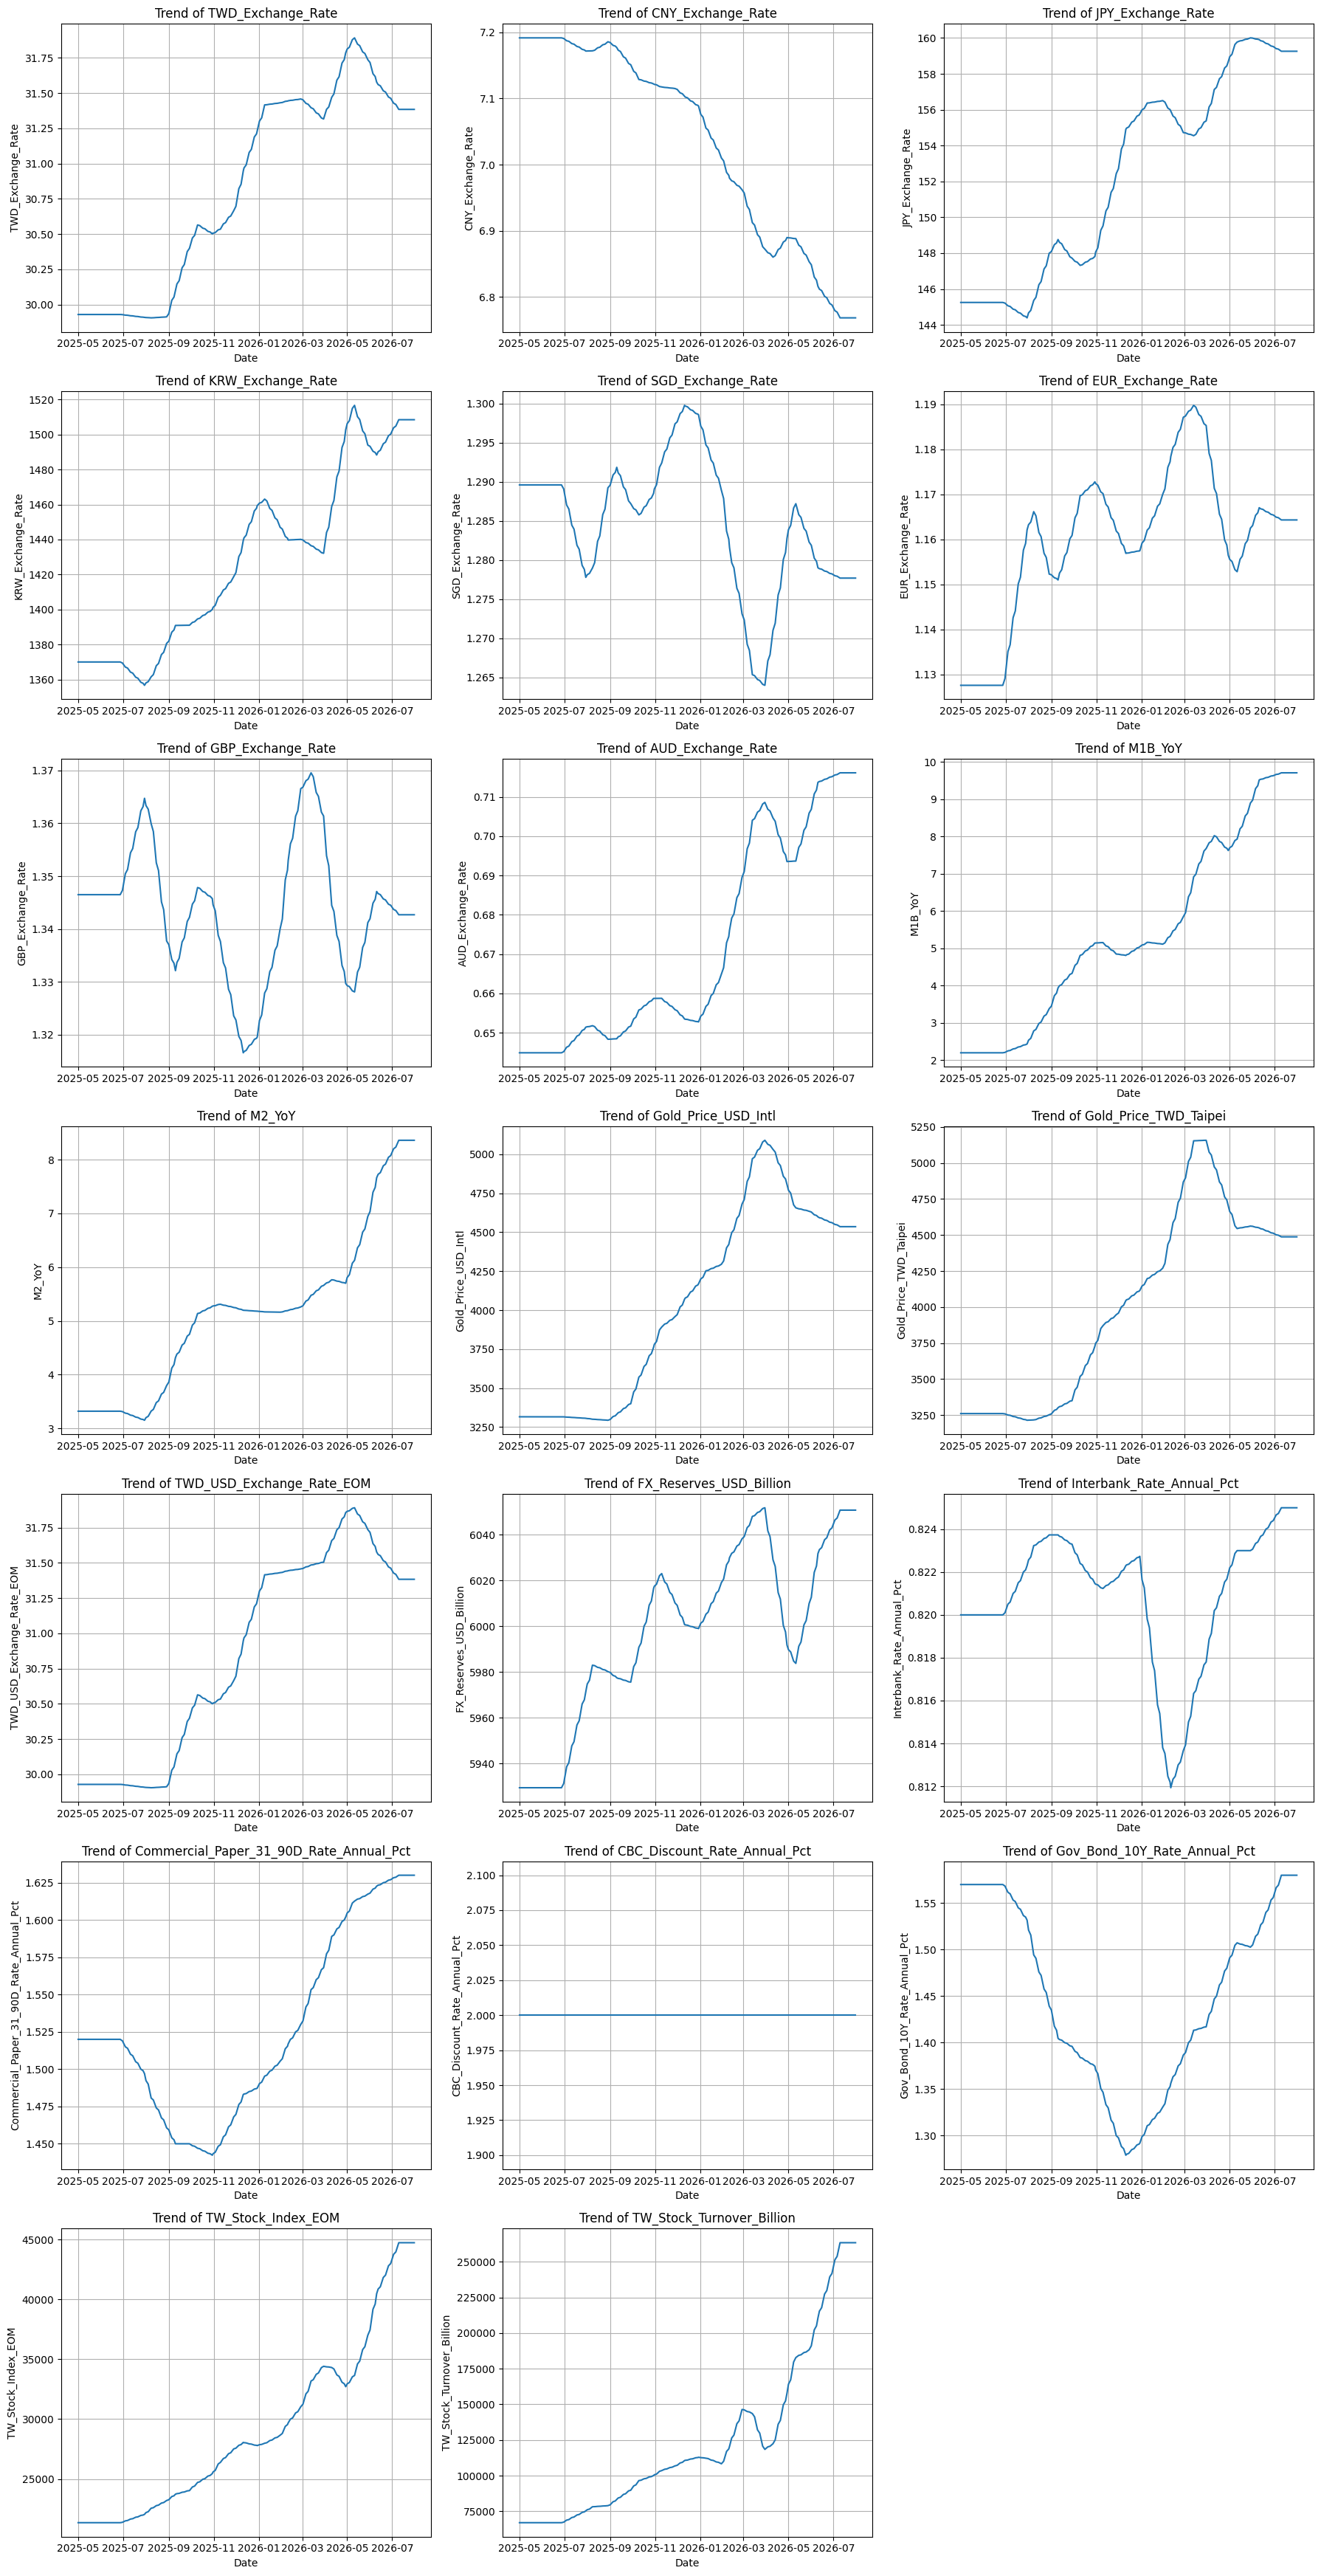

In [99]:

# 獲取 open_gov_deta_smoothed 的欄位數量
num_columns = open_gov_deta_smoothed.shape[1]

# 根據欄位數量創建子圖佈局，每行顯示 3 個圖
# ceil(num_columns / 3) 計算所需的行數
num_rows = (num_columns + 2) // 3

plt.figure(figsize=(18, num_rows * 5)) # 調整整體圖表大小

for i, column in enumerate(open_gov_deta_smoothed.columns):
    plt.subplot(num_rows, 3, i + 1) # (行, 列, 當前圖序)
    plt.plot(open_gov_deta_smoothed.index, open_gov_deta_smoothed[column])
    plt.title(f'Trend of {column}')
    plt.xlabel('Date')
    plt.ylabel(column)
    plt.grid(True)
    plt.tight_layout() # 自動調整子圖間距，防止重疊

plt.show()

## 特徵標準化與二元標籤

In [100]:
import pandas as pd

# 1. 對 tick001_testdf 中的所有特徵進行 Z-Score 標準化
# (x - mean) / std
features_zscored = (tick001_testdf - tick001_testdf.mean()) / tick001_testdf.std()

print("Z-Score 標準化後的特徵數據 (features_zscored) 的前5行：")
display(features_zscored.head())
print("Z-Score 標準化後的特徵數據 (features_zscored) 的基本資訊：")
features_zscored.info()
print("是否存在任何 NaN (標準化後):", features_zscored.isna().any().any())

# 2. 生成未來 30 天漲跌方向的二元分類標籤
# 假設我們要預測台灣加權指數 (TWII) 的漲跌

# 確保 twii DataFrame 存在且包含 'Close' 欄位
if 'twii' not in locals() or not isinstance(twii, pd.DataFrame) or 'Close' not in twii.columns:
    raise ValueError("原始 'twii' DataFrame 或其 'Close' 欄位未找到，無法生成標籤。")

# 從原始的 `twii` DataFrame 中獲取 `Close` 價格，並確保它是一個 Series，以便正確命名。
# 根據 kernel state，twii['Close'] 是一個 DataFrame，其列名是 '^TWII'，所以我們需要提取這個 Series。
twii_close_series = twii['Close']['^TWII']
twii_close_series.name = 'TWII_Close_Price_Base' # 給它一個明確的基礎名稱

# 計算未來 30 個交易日的收盤價
future_30d_close_series = twii_close_series.shift(-30)

# 計算未來 30 天的漲跌
# 如果未來價格高於當前價格，則為漲 (1)，否則為跌 (0)。
target_series = (future_30d_close_series > twii_close_series).astype(int)
target_series.name = 'target_30d_direction' # 明確設定 Series 的名稱

# 將 Series 轉換為 DataFrame，以便與 features_zscored 合併時保持一致，並確保列名為 'target_30d_direction'
price_direction_30d_df = target_series.to_frame()

print("\n未來 30 天漲跌標籤 (target_30d_direction) 的前5行：")
display(price_direction_30d_df.head())
print("未來 30 天漲跌標籤 (target_30d_direction) 的後5行 (應有 NaN)：")
display(price_direction_30d_df.tail())
print(f"標籤中 1 (漲) 的數量: {(price_direction_30d_df == 1).sum().iloc[0]}")
print(f"標籤中 0 (跌) 的數量: {(price_direction_30d_df == 0).sum().iloc[0]}")

# 3. 將標準化後的特徵與標籤合併
# 使用 `left_index=True, right_index=True` 確保根據日期索引合併
# `how='inner'` 會自動去除因為 shift(-30) 導致的 NaN 行
# 由於 price_direction_30d_df 的列名已經是 'target_30d_direction'，不會與 features_zscored 中的 '^TWII' 衝突，故不會產生 '_y' 後綴。
final_features_and_target = pd.merge(
    features_zscored,
    price_direction_30d_df,
    left_index=True,
    right_index=True,
    how='inner'
)

print("\n合併特徵與標籤後的數據 (final_features_and_target) 的前5行：")
display(final_features_and_target.head())
print("合併特徵與標籤後的數據 (final_features_and_target) 的基本資訊：")
final_features_and_target.info()
print("是否存在任何 NaN (最終數據集):", final_features_and_target.isna().any().any())

Z-Score 標準化後的特徵數據 (features_zscored) 的前5行：


,2308.TW,2317.TW,2330.TW,2382.TW,2412.TW,2454.TW,2603.TW,2881.TW,GC=F,^TNX,...,^GDAXI,^N225,^GSPC,^VIX,^IXIC,^TWII,0051.TW,CPI_YoY,T10Y2Y_Spread,Taiwan_Export_YoY
Date,,,,,,,,,,,,,,,,,,,,,
2011-01-03,-0.496047,-0.73218,-0.768434,-0.676664,-1.595407,-0.559973,-0.538372,-0.921914,-0.466101,0.684424,...,-1.247254,-1.163228,-1.193374,-0.090874,-1.104974,-0.642631,-0.621902,-0.505126,2.125893,-1.360377
2011-01-04,-0.496047,-0.73218,-0.768434,-0.676664,-1.595407,-0.559973,-0.538372,-0.921914,-0.494014,0.686341,...,-1.248768,-1.163228,-1.193892,-0.110018,-1.105828,-0.644708,-0.626059,-0.505126,2.114535,-1.360377
2011-01-05,-0.496047,-0.73218,-0.768434,-0.676664,-1.595407,-0.559973,-0.538372,-0.921914,-0.505470,0.730756,...,-1.251765,-1.163987,-1.192749,-0.136377,-1.104951,-0.652833,-0.631428,-0.505126,2.133465,-1.360377
2011-01-06,-0.496047,-0.73218,-0.768434,-0.676664,-1.595407,-0.559973,-0.538372,-0.921914,-0.511831,0.737626,...,-1.251077,-1.159893,-1.192598,-0.133741,-1.104193,-0.655533,-0.631580,-0.505126,2.134411,-1.360377
2011-01-07,-0.496047,-0.73218,-0.768434,-0.676664,-1.595407,-0.559973,-0.538372,-0.921914,-0.516381,0.724302,...,-1.252075,-1.157600,-1.192799,-0.140816,-1.103961,-0.660122,-0.634684,-0.505126,2.130436,-1.360377


Z-Score 標準化後的特徵數據 (features_zscored) 的基本資訊：
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4070 entries, 2011-01-03 to 2026-07-31
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   2308.TW            4070 non-null   float64
 1   2317.TW            4070 non-null   float64
 2   2330.TW            4070 non-null   float64
 3   2382.TW            4070 non-null   float64
 4   2412.TW            4070 non-null   float64
 5   2454.TW            4070 non-null   float64
 6   2603.TW            4070 non-null   float64
 7   2881.TW            4070 non-null   float64
 8   GC=F               4070 non-null   float64
 9   ^TNX               4070 non-null   float64
 10  CL=F               4070 non-null   float64
 11  ^DJI               4070 non-null   float64
 12  ^GDAXI             4070 non-null   float64
 13  ^N225              4070 non-null   float64
 14  ^GSPC              4070 non-null   float64
 15  ^VIX      

,target_30d_direction
Date,
2011-01-03,0
2011-01-04,0
2011-01-05,0
2011-01-06,0
2011-01-07,0


未來 30 天漲跌標籤 (target_30d_direction) 的後5行 (應有 NaN)：


,target_30d_direction
Date,
2026-07-24,0
2026-07-27,0
2026-07-28,0
2026-07-29,0
2026-07-30,0


標籤中 1 (漲) 的數量: 2342
標籤中 0 (跌) 的數量: 1453

合併特徵與標籤後的數據 (final_features_and_target) 的前5行：


,2308.TW,2317.TW,2330.TW,2382.TW,2412.TW,2454.TW,2603.TW,2881.TW,GC=F,^TNX,...,^N225,^GSPC,^VIX,^IXIC,^TWII,0051.TW,CPI_YoY,T10Y2Y_Spread,Taiwan_Export_YoY,target_30d_direction
Date,,,,,,,,,,,,,,,,,,,,,
2011-01-03,-0.496047,-0.73218,-0.768434,-0.676664,-1.595407,-0.559973,-0.538372,-0.921914,-0.466101,0.684424,...,-1.163228,-1.193374,-0.090874,-1.104974,-0.642631,-0.621902,-0.505126,2.125893,-1.360377,0
2011-01-04,-0.496047,-0.73218,-0.768434,-0.676664,-1.595407,-0.559973,-0.538372,-0.921914,-0.494014,0.686341,...,-1.163228,-1.193892,-0.110018,-1.105828,-0.644708,-0.626059,-0.505126,2.114535,-1.360377,0
2011-01-05,-0.496047,-0.73218,-0.768434,-0.676664,-1.595407,-0.559973,-0.538372,-0.921914,-0.505470,0.730756,...,-1.163987,-1.192749,-0.136377,-1.104951,-0.652833,-0.631428,-0.505126,2.133465,-1.360377,0
2011-01-06,-0.496047,-0.73218,-0.768434,-0.676664,-1.595407,-0.559973,-0.538372,-0.921914,-0.511831,0.737626,...,-1.159893,-1.192598,-0.133741,-1.104193,-0.655533,-0.631580,-0.505126,2.134411,-1.360377,0
2011-01-07,-0.496047,-0.73218,-0.768434,-0.676664,-1.595407,-0.559973,-0.538372,-0.921914,-0.516381,0.724302,...,-1.157600,-1.192799,-0.140816,-1.103961,-0.660122,-0.634684,-0.505126,2.130436,-1.360377,0


合併特徵與標籤後的數據 (final_features_and_target) 的基本資訊：
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3795 entries, 2011-01-03 to 2026-07-30
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   2308.TW               3795 non-null   float64
 1   2317.TW               3795 non-null   float64
 2   2330.TW               3795 non-null   float64
 3   2382.TW               3795 non-null   float64
 4   2412.TW               3795 non-null   float64
 5   2454.TW               3795 non-null   float64
 6   2603.TW               3795 non-null   float64
 7   2881.TW               3795 non-null   float64
 8   GC=F                  3795 non-null   float64
 9   ^TNX                  3795 non-null   float64
 10  CL=F                  3795 non-null   float64
 11  ^DJI                  3795 non-null   float64
 12  ^GDAXI                3795 non-null   float64
 13  ^N225                 3795 non-null   float64
 14  ^GSPC  

現在，讓我們來計算 `final_features_and_target` 資料框的相關性矩陣，並繪製熱力圖，以便視覺化所有特徵與目標變數之間的關聯性。這將有助於我們理解哪些特徵與預測目標的關係較強。

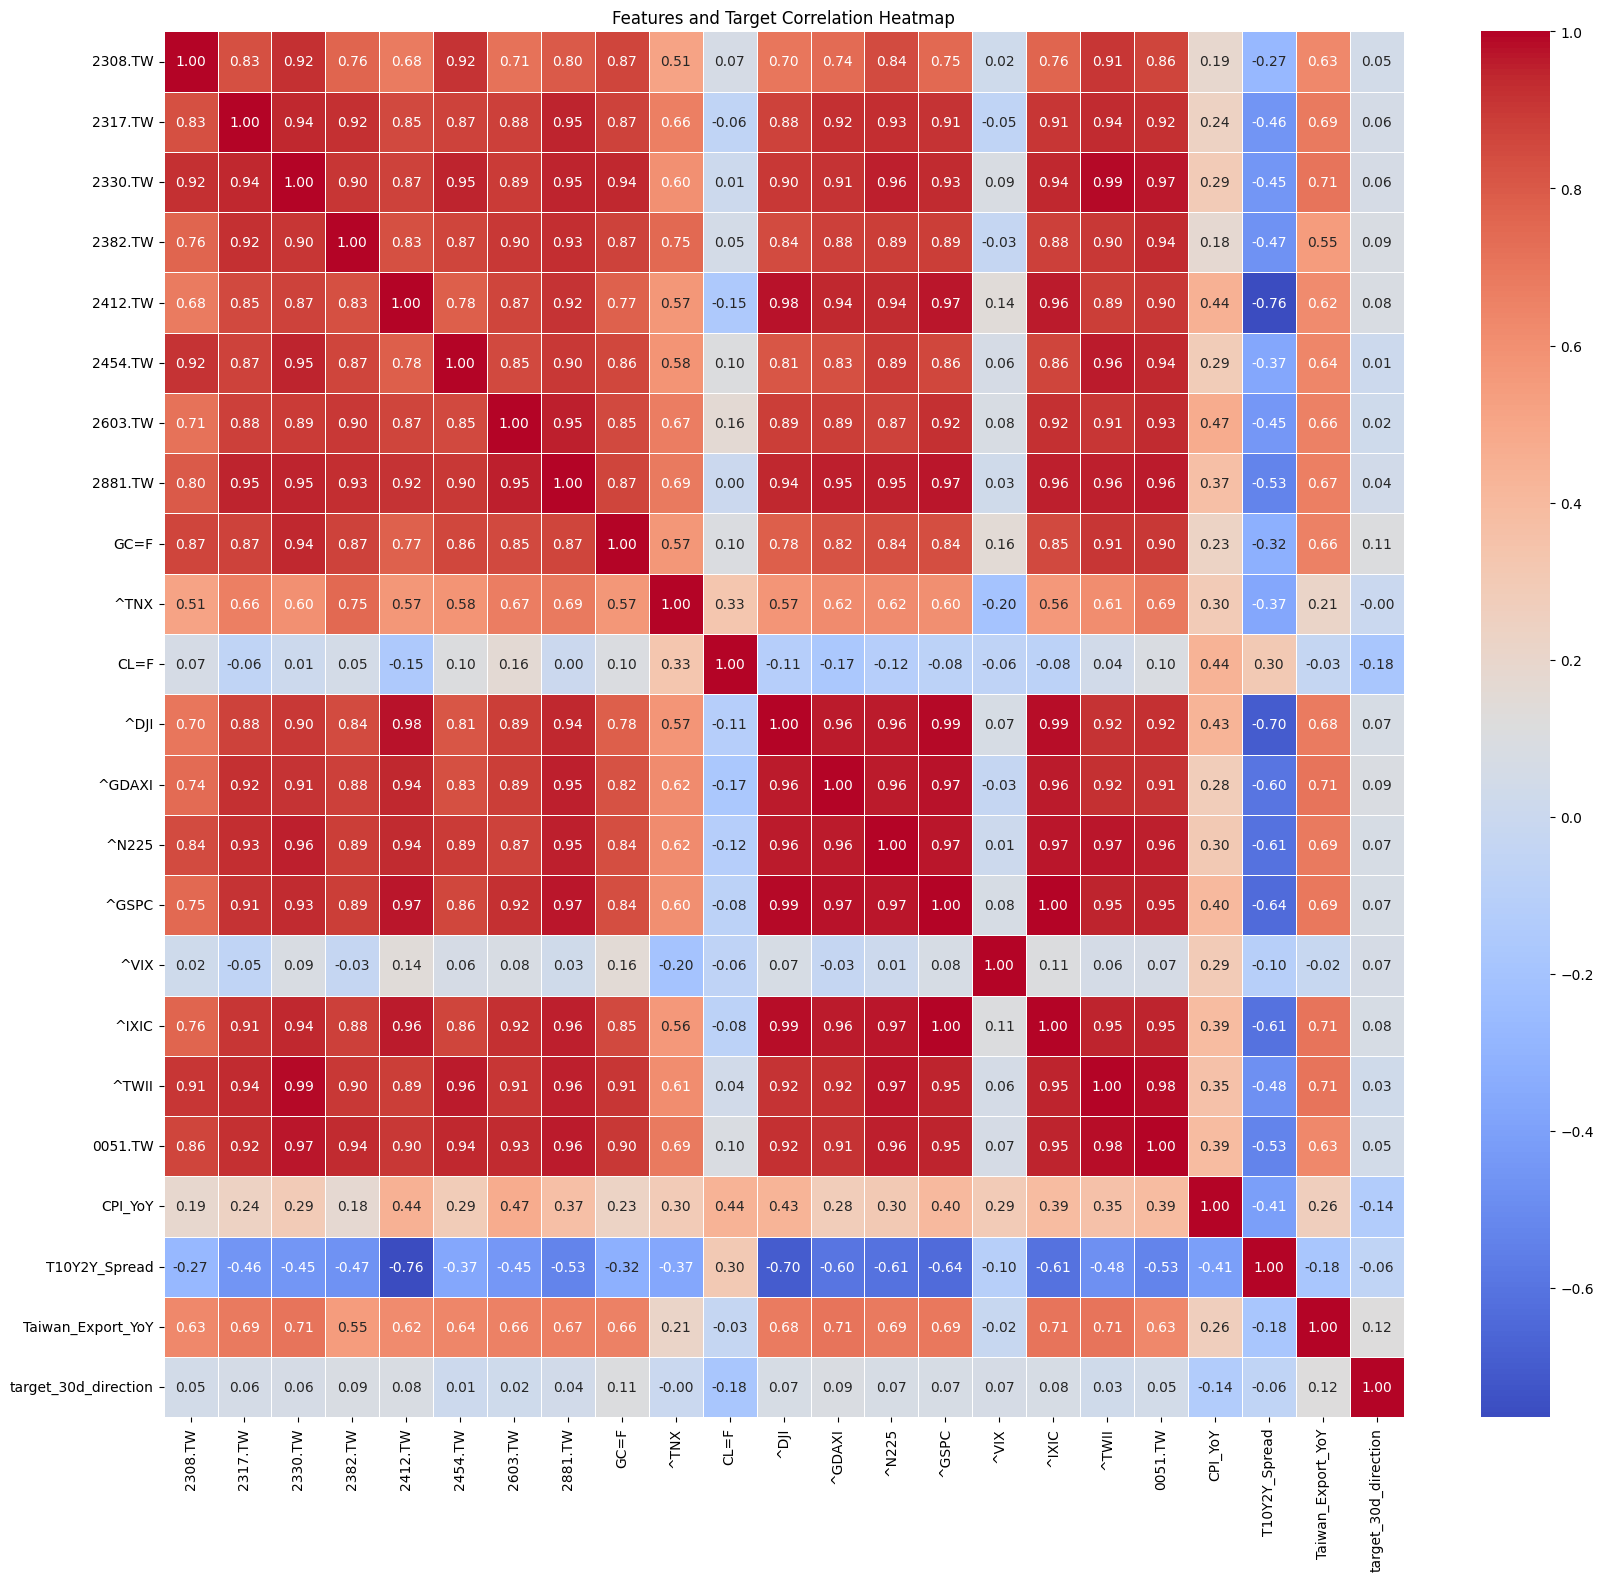

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

# 計算相關性矩陣
correlation_matrix = final_features_and_target.corr()

# 繪製熱力圖
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Features and Target Correlation Heatmap')
plt.show()

初步測試

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import numpy as np


# 將最終的特徵和目標數據分離
X_processed = final_features_and_target.drop(columns=['target_30d_direction'])
y = final_features_and_target['target_30d_direction']

# 將資料切分為訓練集和測試集 (80% 訓練, 20% 測試)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"訓練集特徵形狀: {X_train.shape}")
print(f"測試集特徵形狀: {X_test.shape}")
print(f"訓練集目標形狀: {y_train.shape}")
print(f"測試集目標形狀: {y_test.shape}")

print("\n資料已成功切分為訓練集和測試集。接下來可以訓練 Random Forest 模型了！")

訓練集特徵形狀: (3036, 22)
測試集特徵形狀: (759, 22)
訓練集目標形狀: (3036,)
測試集目標形狀: (759,)

資料已成功切分為訓練集和測試集。接下來可以訓練 Random Forest 模型了！
